# EDA 2 : Deep Dives

Focused analyses on the high-potential avenues identified in EDA 1.

**Deep-dive topics:**
1. Spark spread — non-linearity and regimes
2. Thermal need × Gas price — key interaction
3. Seasonal difficulty — why July-August are so hard
4. FR Nuclear — lag, thresholds, interactions
5. UK wind — negative price thresholds, non-linearity
6. Price regimes — crisis vs normal
7. Interconnector congestion — market decoupling

In [21]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

from src.data_loading import load_data, merge_train

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['figure.dpi'] = 110

x_train, y_train, x_test = load_data()
train = merge_train(x_train, y_train)
dt = train['datetime_CET']

# Forward-fill daily columns
DAILY_COLS = ['de_gas', 'es_gas', 'fr_gas', 'nl_gas', 'uk_gas', 'eu_emission', 'uk_emission']
for col in DAILY_COLS:
    train[col] = train[col].ffill()

# Pre-compute key derived features and append with concat to avoid fragmentation
GAS_EFF = 0.50
EM_FACTOR = 0.37
derived_features = {
    'fr_residual': train['fr_load_f'] - train['fr_solar_f'] - train['fr_wind_f'],
    'uk_residual': train['uk_load_f'] - train['uk_solar_f'] - train['uk_wind_f'],
    'fr_spark': train['fr_gas'] / GAS_EFF + train['eu_emission'] * EM_FACTOR,
    'uk_spark': train['uk_gas'] / GAS_EFF + train['uk_emission'] * EM_FACTOR,
    'fr_wind_pen': train['fr_wind_f'] / train['fr_load_f'].clip(lower=1),
    'uk_wind_pen': train['uk_wind_f'] / train['uk_load_f'].clip(lower=1),
    'spread_fr_uk': train['fr_spot'] - train['uk_spot'],
}
derived_features['fr_thermal_need'] = derived_features['fr_residual'] - train['fr_nuclear_avcap_f']
derived_features['uk_thermal_need'] = derived_features['uk_residual'] - train['uk_nuclear_avcap_f']

derived_df = pd.DataFrame(derived_features, index=train.index)
train = pd.concat([train.drop(columns=derived_df.columns, errors='ignore'), derived_df], axis=1).copy()

print('Data loaded. Starting deep dives.')

Data loaded. Starting deep dives.


---
## 1. Spark Spread — Relationship structure and regimes

The spark spread approximates the marginal thermal generation cost. This section tests where spark tracks spot prices well and where it breaks down by hour and market regime.

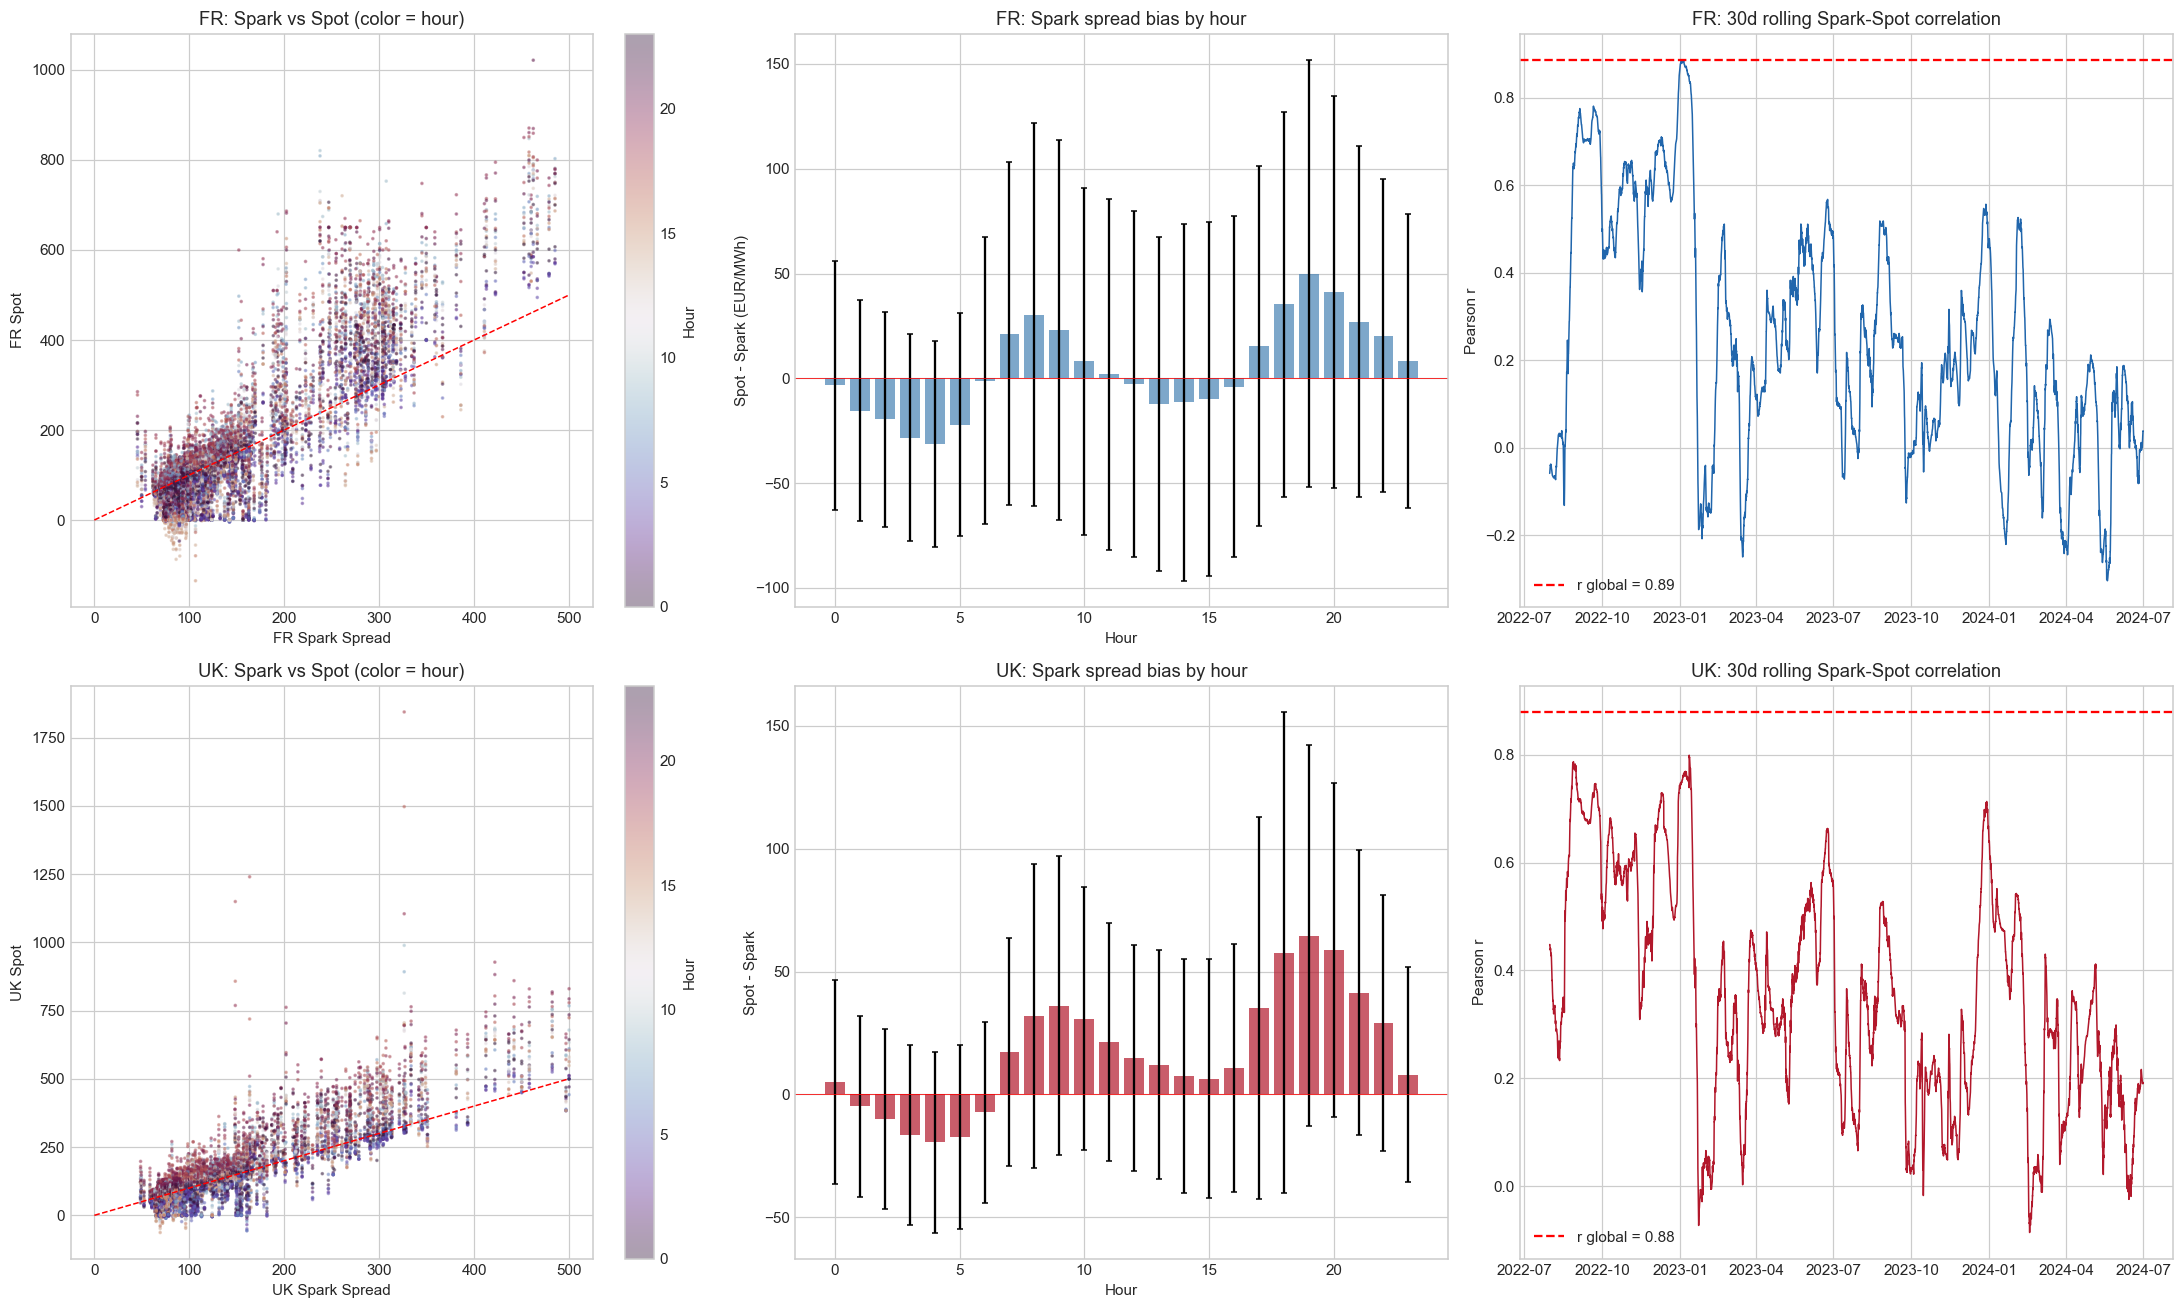

When the spark spread does not hold:

FR — Spot << Spark (below p5 residual, cutoff=-92.4) :
  878 hours (5.0%)
  Mean hour: 10h
  Wind penetration: 18.5% (vs normal 10.6%)
  Nuclear: 38947 MW (vs normal 38528)

FR — Spot >> Spark (above p95 residual, cutoff=179.3) :
  878 hours (5.0%)
  Nuclear: 28855 MW (vs normal 38528)
  Thermal need: 17507 MW (vs normal 3084)


In [22]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

mask = train['fr_spark'].notna()
fr_s = train[mask]

# 1a. Scatter colored by hour — does the spark hold across all hours?
sc = axes[0, 0].scatter(fr_s['fr_spark'], fr_s['fr_spot'], c=fr_s['datetime_CET'].dt.hour,
                        cmap='twilight_shifted', s=2, alpha=0.4)
axes[0, 0].plot([0, 500], [0, 500], 'r--', linewidth=1)
axes[0, 0].set_xlabel('FR Spark Spread')
axes[0, 0].set_ylabel('FR Spot')
axes[0, 0].set_title('FR: Spark vs Spot (color = hour)')
plt.colorbar(sc, ax=axes[0, 0], label='Hour')

# 1b. Spot - spark residual by hour
fr_s = fr_s.copy()
fr_s['spark_resid'] = fr_s['fr_spot'] - fr_s['fr_spark']
resid_by_hour = fr_s.groupby(fr_s['datetime_CET'].dt.hour)['spark_resid'].agg(['mean', 'std'])
axes[0, 1].bar(resid_by_hour.index, resid_by_hour['mean'], color='steelblue', alpha=0.7)
axes[0, 1].errorbar(resid_by_hour.index, resid_by_hour['mean'], yerr=resid_by_hour['std'],
                    fmt='none', color='black', capsize=2)
axes[0, 1].axhline(0, color='red', linewidth=0.5)
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Spot - Spark (EUR/MWh)')
axes[0, 1].set_title('FR: Spark spread bias by hour')

# 1c. Rolling spark-spot correlation (regimes)
window = 720  # 30 days
mask_both = train['fr_spark'].notna()
rolling_r = train.loc[mask_both, 'fr_spot'].rolling(window).corr(train.loc[mask_both, 'fr_spark'])
fr_global_r = train.loc[mask_both, 'fr_spot'].corr(train.loc[mask_both, 'fr_spark'])
axes[0, 2].plot(train.loc[mask_both, 'datetime_CET'], rolling_r, linewidth=1, color='#2166ac')
axes[0, 2].axhline(fr_global_r, color='red', linestyle='--', label=f'r global = {fr_global_r:.2f}')
axes[0, 2].set_title('FR: 30d rolling Spark-Spot correlation')
axes[0, 2].set_ylabel('Pearson r')
axes[0, 2].legend()

# UK
mask = train['uk_spark'].notna()
uk_s = train[mask].copy()

sc = axes[1, 0].scatter(uk_s['uk_spark'], uk_s['uk_spot'], c=uk_s['datetime_CET'].dt.hour,
                        cmap='twilight_shifted', s=2, alpha=0.4)
axes[1, 0].plot([0, 500], [0, 500], 'r--', linewidth=1)
axes[1, 0].set_xlabel('UK Spark Spread')
axes[1, 0].set_ylabel('UK Spot')
axes[1, 0].set_title('UK: Spark vs Spot (color = hour)')
plt.colorbar(sc, ax=axes[1, 0], label='Hour')

uk_s['spark_resid'] = uk_s['uk_spot'] - uk_s['uk_spark']
resid_by_hour = uk_s.groupby(uk_s['datetime_CET'].dt.hour)['spark_resid'].agg(['mean', 'std'])
axes[1, 1].bar(resid_by_hour.index, resid_by_hour['mean'], color='#b2182b', alpha=0.7)
axes[1, 1].errorbar(resid_by_hour.index, resid_by_hour['mean'], yerr=resid_by_hour['std'],
                    fmt='none', color='black', capsize=2)
axes[1, 1].axhline(0, color='red', linewidth=0.5)
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Spot - Spark')
axes[1, 1].set_title('UK: Spark spread bias by hour')

rolling_r = train.loc[mask, 'uk_spot'].rolling(window).corr(train.loc[mask, 'uk_spark'])
uk_global_r = train.loc[mask, 'uk_spot'].corr(train.loc[mask, 'uk_spark'])
axes[1, 2].plot(train.loc[mask, 'datetime_CET'], rolling_r, linewidth=1, color='#b2182b')
axes[1, 2].axhline(uk_global_r, color='red', linestyle='--', label=f'r global = {uk_global_r:.2f}')
axes[1, 2].set_title('UK: 30d rolling Spark-Spot correlation')
axes[1, 2].set_ylabel('Pearson r')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

# Analysis: when the spark breaks down (quantile-based thresholds)
print('When the spark spread does not hold:')
low_cutoff = fr_s['spark_resid'].quantile(0.05)
high_cutoff = fr_s['spark_resid'].quantile(0.95)

print(f'\nFR — Spot << Spark (below p5 residual, cutoff={low_cutoff:.1f}) :')
low_resid = fr_s[fr_s['spark_resid'] < low_cutoff]
print(f'  {len(low_resid)} hours ({100*len(low_resid)/len(fr_s):.1f}%)')
print(f'  Mean hour: {low_resid["datetime_CET"].dt.hour.mean():.0f}h')
print(f'  Wind penetration: {low_resid["fr_wind_pen"].mean()*100:.1f}% (vs normal {fr_s["fr_wind_pen"].mean()*100:.1f}%)')
print(f'  Nuclear: {low_resid["fr_nuclear_avcap_f"].mean():.0f} MW (vs normal {fr_s["fr_nuclear_avcap_f"].mean():.0f})')

print(f'\nFR — Spot >> Spark (above p95 residual, cutoff={high_cutoff:.1f}) :')
high_resid = fr_s[fr_s['spark_resid'] > high_cutoff]
print(f'  {len(high_resid)} hours ({100*len(high_resid)/len(fr_s):.1f}%)')
print(f'  Nuclear: {high_resid["fr_nuclear_avcap_f"].mean():.0f} MW (vs normal {fr_s["fr_nuclear_avcap_f"].mean():.0f})')
print(f'  Thermal need: {high_resid["fr_thermal_need"].mean():.0f} MW (vs normal {fr_s["fr_thermal_need"].mean():.0f})')

---
## 2. Thermal Need × Gas Price interaction

Hypothesis: gas-price sensitivity is regime-dependent. When thermal need is positive (thermal stack marginal), spot should track gas more closely; when thermal need is low/negative, the relationship should weaken.

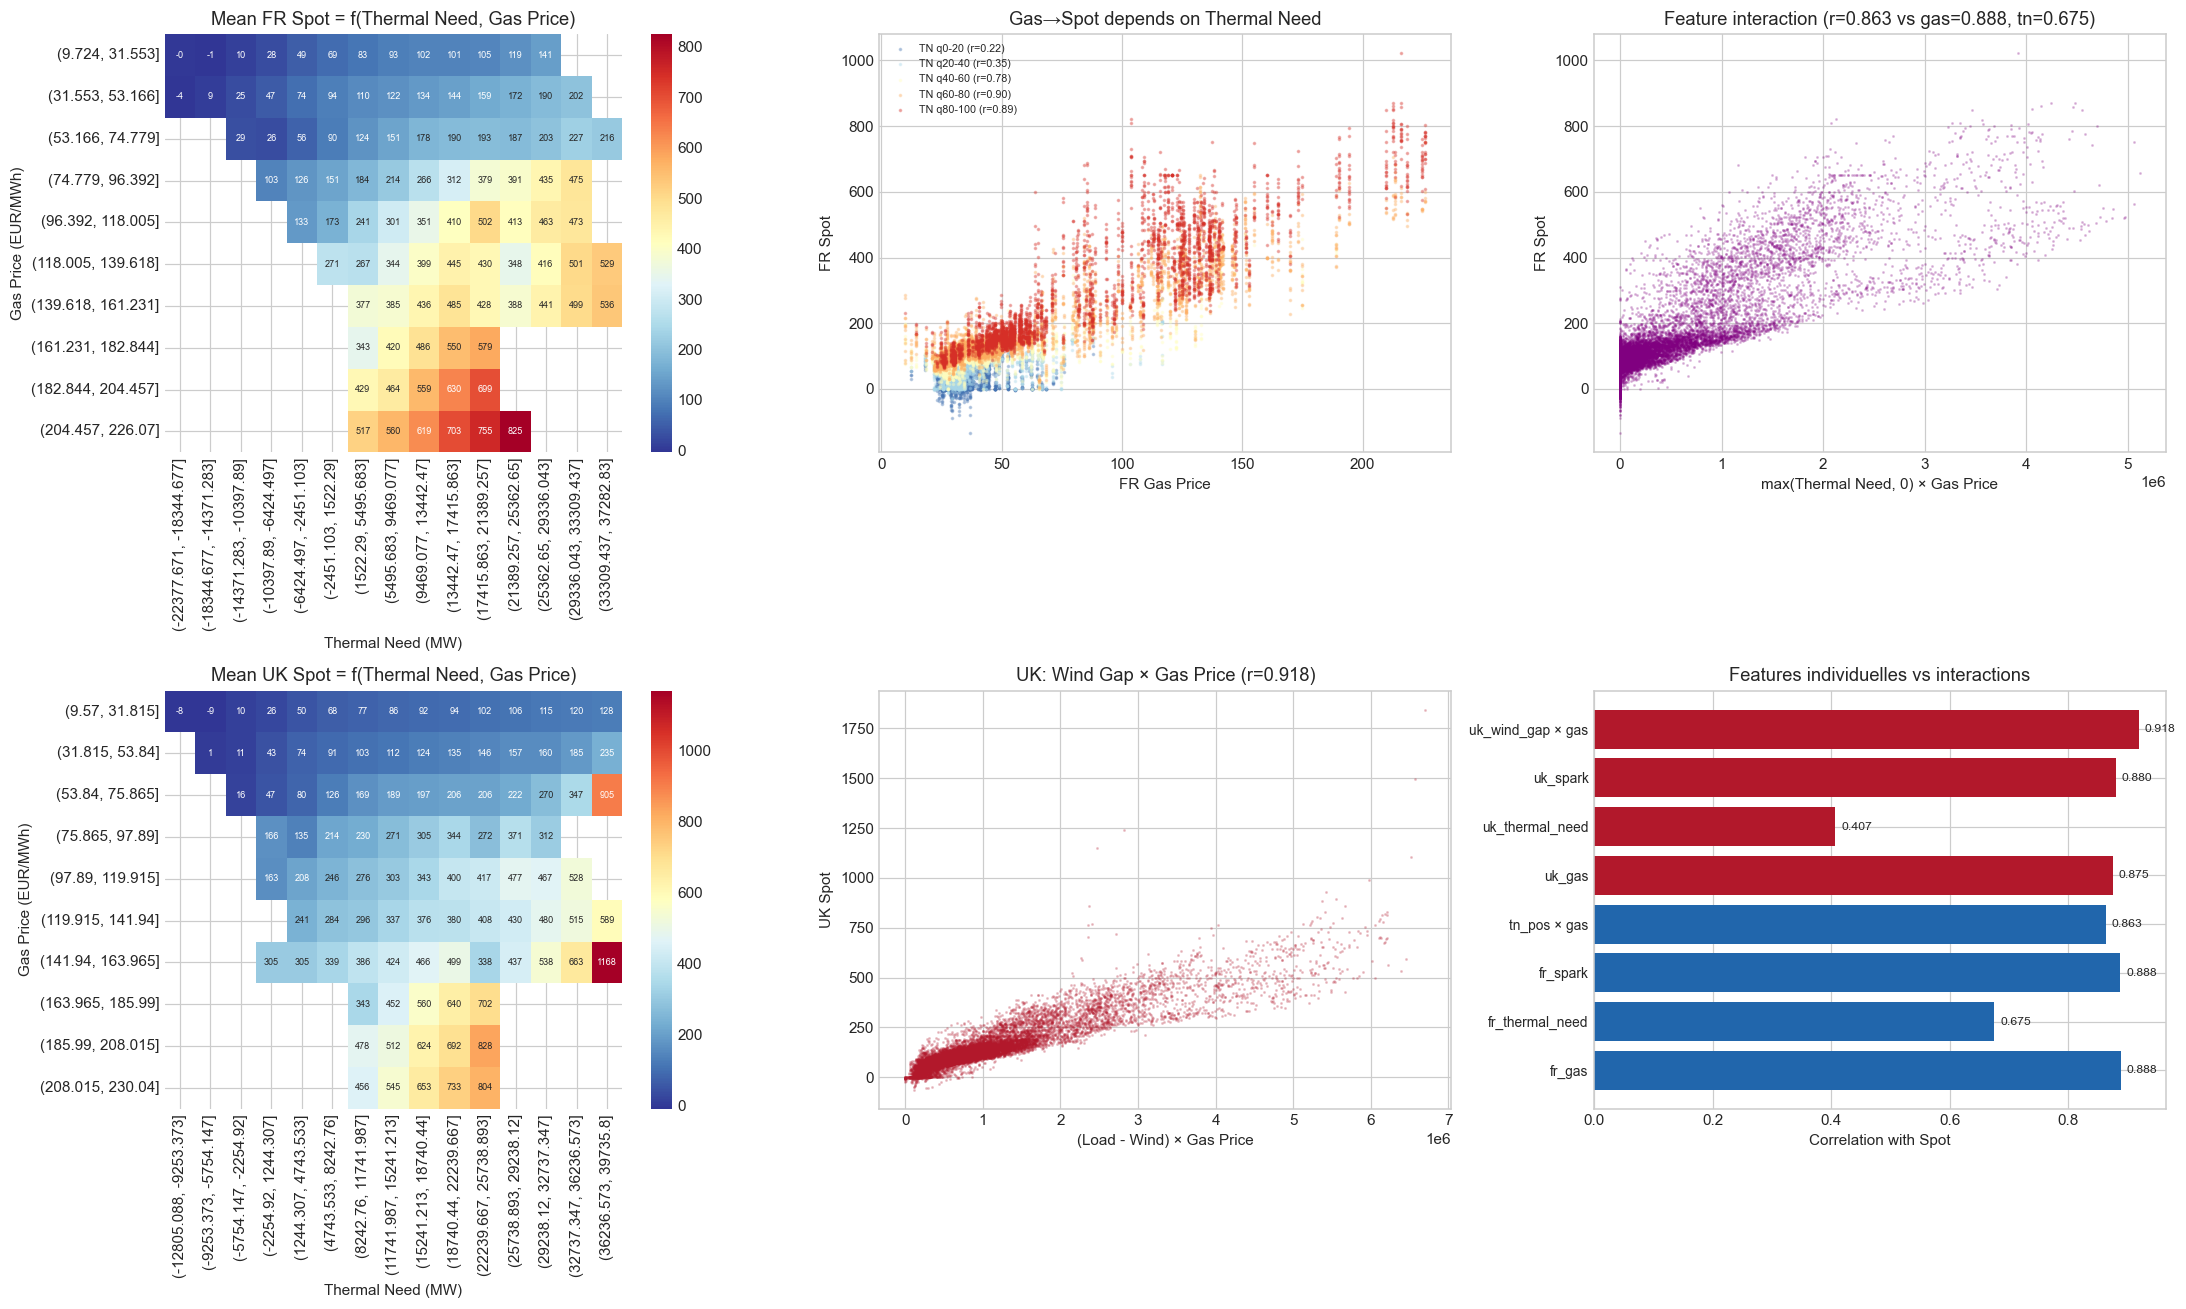

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

mask = train['fr_gas'].notna()
sub = train[mask].copy()

# 2a. 3D view : thermal need × gas price → spot (heatmap binned)
sub['tn_bin'] = pd.cut(sub['fr_thermal_need'], bins=15)
sub['gas_bin'] = pd.cut(sub['fr_gas'], bins=10)
pivot = sub.pivot_table(values='fr_spot', index='gas_bin', columns='tn_bin', aggfunc='mean')

ax = axes[0, 0]
sns.heatmap(pivot, ax=ax, cmap='RdYlBu_r', annot=True, fmt='.0f', annot_kws={'size': 6})
ax.set_title('Mean FR Spot = f(Thermal Need, Gas Price)')
ax.set_xlabel('Thermal Need (MW)')
ax.set_ylabel('Gas Price (EUR/MWh)')

# 2b. Gas-spot correlation conditional on thermal need
ax = axes[0, 1]
tn_quantiles = sub['fr_thermal_need'].quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0])
colors = plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, 5))
for i in range(5):
    mask_q = (sub['fr_thermal_need'] >= tn_quantiles.iloc[i]) & (sub['fr_thermal_need'] < tn_quantiles.iloc[i+1])
    r = sub.loc[mask_q, 'fr_gas'].corr(sub.loc[mask_q, 'fr_spot'])
    label = f'TN q{i*20}-{(i+1)*20} (r={r:.2f})'
    ax.scatter(sub.loc[mask_q, 'fr_gas'], sub.loc[mask_q, 'fr_spot'], 
              s=2, alpha=0.3, color=colors[i], label=label)
ax.set_xlabel('FR Gas Price')
ax.set_ylabel('FR Spot')
ax.set_title('Gas→Spot depends on Thermal Need')
ax.legend(fontsize=7, loc='upper left')

# 2c. Candidate feature: thermal_need × gas_price
sub['tn_x_gas'] = sub['fr_thermal_need'].clip(lower=0) * sub['fr_gas']
r_tn_gas = sub['tn_x_gas'].corr(sub['fr_spot'])
r_gas = sub['fr_gas'].corr(sub['fr_spot'])
r_tn = sub['fr_thermal_need'].corr(sub['fr_spot'])

ax = axes[0, 2]
ax.scatter(sub['tn_x_gas'], sub['fr_spot'], s=1, alpha=0.2, color='purple')
ax.set_xlabel('max(Thermal Need, 0) × Gas Price')
ax.set_ylabel('FR Spot')
ax.set_title(f'Feature interaction (r={r_tn_gas:.3f} vs gas={r_gas:.3f}, tn={r_tn:.3f})')

# UK version
mask_uk = train['uk_gas'].notna()
sub_uk = train[mask_uk].copy()

sub_uk['tn_bin'] = pd.cut(sub_uk['uk_thermal_need'], bins=15)
sub_uk['gas_bin'] = pd.cut(sub_uk['uk_gas'], bins=10)
pivot_uk = sub_uk.pivot_table(values='uk_spot', index='gas_bin', columns='tn_bin', aggfunc='mean')

ax = axes[1, 0]
sns.heatmap(pivot_uk, ax=ax, cmap='RdYlBu_r', annot=True, fmt='.0f', annot_kws={'size': 6})
ax.set_title('Mean UK Spot = f(Thermal Need, Gas Price)')
ax.set_xlabel('Thermal Need (MW)')
ax.set_ylabel('Gas Price (EUR/MWh)')

# UK wind × gas interaction
sub_uk['wind_gap'] = sub_uk['uk_load_f'] - sub_uk['uk_wind_f']  # what wind doesn't cover
sub_uk['wind_gap_x_gas'] = sub_uk['wind_gap'].clip(lower=0) * sub_uk['uk_gas']
r_wg = sub_uk['wind_gap_x_gas'].corr(sub_uk['uk_spot'])

ax = axes[1, 1]
ax.scatter(sub_uk['wind_gap_x_gas'], sub_uk['uk_spot'], s=1, alpha=0.2, color='#b2182b')
ax.set_xlabel('(Load - Wind) × Gas Price')
ax.set_ylabel('UK Spot')
ax.set_title(f'UK: Wind Gap × Gas Price (r={r_wg:.3f})')

# Comparison bar chart : individual vs interaction features
ax = axes[1, 2]
feats = {
    'fr_gas': sub['fr_gas'].corr(sub['fr_spot']),
    'fr_thermal_need': sub['fr_thermal_need'].corr(sub['fr_spot']),
    'fr_spark': sub['fr_spark'].corr(sub['fr_spot']),
    'tn_pos × gas': r_tn_gas,
    'uk_gas': sub_uk['uk_gas'].corr(sub_uk['uk_spot']),
    'uk_thermal_need': sub_uk['uk_thermal_need'].corr(sub_uk['uk_spot']),
    'uk_spark': sub_uk['uk_spark'].corr(sub_uk['uk_spot']),
    'uk_wind_gap × gas': r_wg,
}
colors = ['#2166ac']*4 + ['#b2182b']*4
ax.barh(range(len(feats)), list(feats.values()), color=colors)
ax.set_yticks(range(len(feats)))
ax.set_yticklabels(feats.keys(), fontsize=9)
ax.set_xlabel('Correlation with Spot')
ax.set_title('Features individuelles vs interactions')
for i, v in enumerate(feats.values()):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

---
## 3. Why July-August are so hard to predict

The RMSE of the 24h naive baseline is 3-4x higher in summer than in winter. Why? And how can we predict these months better?

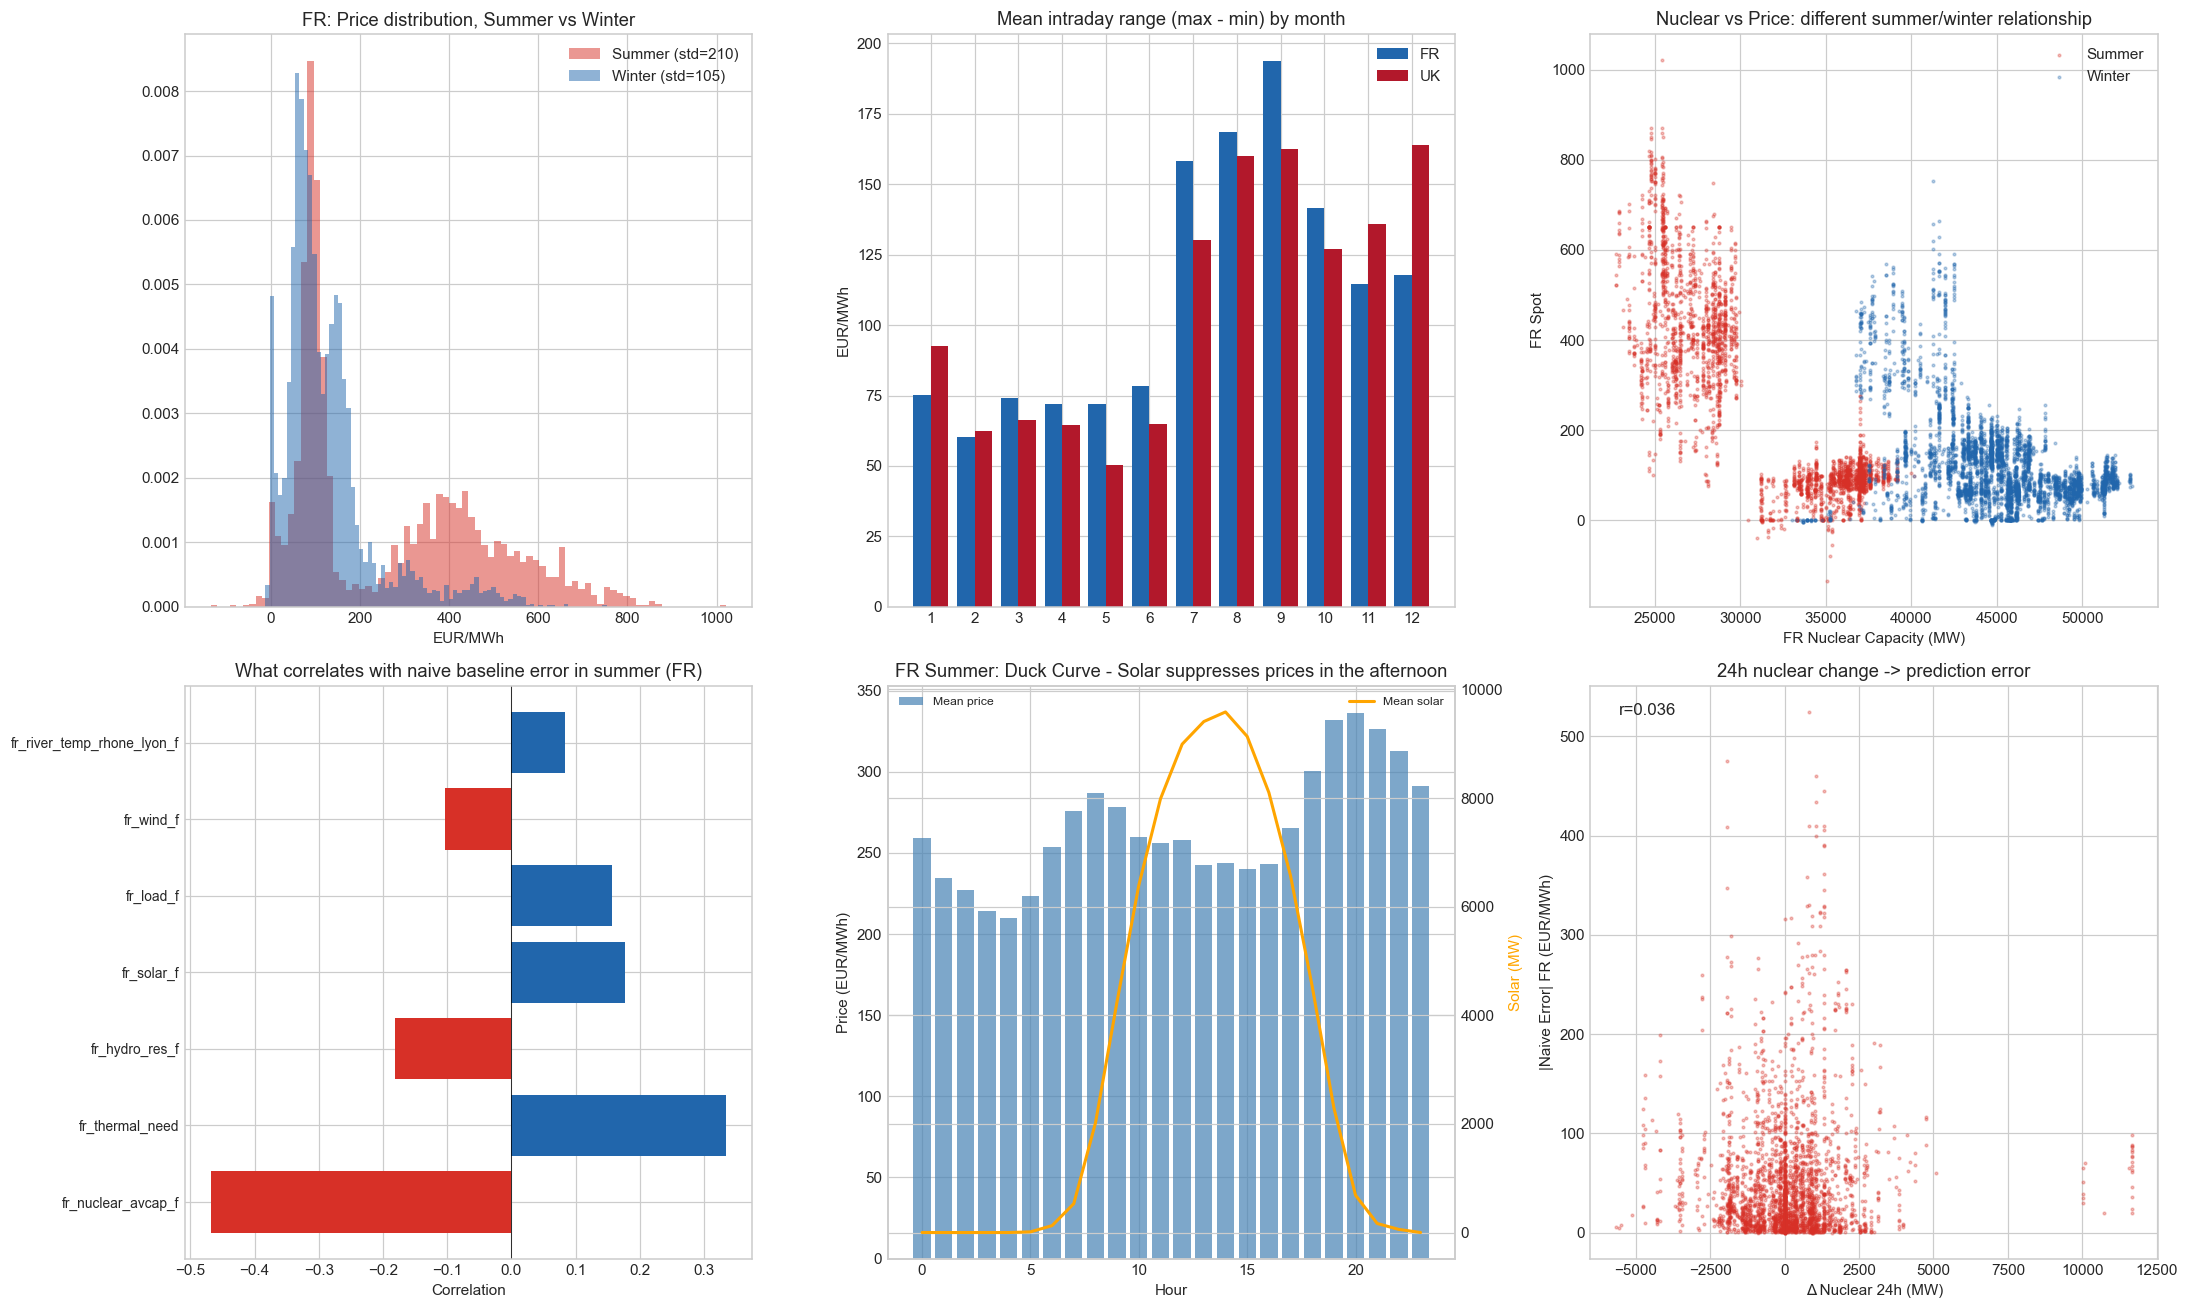


--- Summer vs Winter ---
FR Spot std — Summer: 210.2, Winter: 105.1
UK Spot std — Summer: 170.2, Winter: 108.3
FR Nuclear mean — Summer: 31431 MW, Winter: 45021 MW


In [24]:
# Separate summer (JJA) vs the rest
summer = train[dt.dt.month.isin([7, 8])].copy()
winter = train[dt.dt.month.isin([12, 1, 2])].copy()
rest = train[~dt.dt.month.isin([7, 8])].copy()

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 3a. Price distribution: summer vs winter
axes[0, 0].hist(summer['fr_spot'], bins=80, alpha=0.5, label=f'Summer (std={summer["fr_spot"].std():.0f})', 
                density=True, color='#d73027')
axes[0, 0].hist(winter['fr_spot'], bins=80, alpha=0.5, label=f'Winter (std={winter["fr_spot"].std():.0f})', 
                density=True, color='#2166ac')
axes[0, 0].set_title('FR: Price distribution, Summer vs Winter')
axes[0, 0].set_xlabel('EUR/MWh')
axes[0, 0].legend()

# 3b. Intraday volatility (daily max-min range)
train['date'] = dt.dt.date
daily_range = train.groupby('date').agg(
    fr_range=('fr_spot', lambda x: x.max() - x.min()),
    uk_range=('uk_spot', lambda x: x.max() - x.min()),
    month=('datetime_CET', lambda x: x.dt.month.iloc[0])
)

monthly_range = daily_range.groupby('month').agg(
    fr_mean=('fr_range', 'mean'),
    uk_mean=('uk_range', 'mean')
)
x = np.arange(12)
axes[0, 1].bar(x - 0.2, monthly_range['fr_mean'], 0.4, label='FR', color='#2166ac')
axes[0, 1].bar(x + 0.2, monthly_range['uk_mean'], 0.4, label='UK', color='#b2182b')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(range(1, 13))
axes[0, 1].set_title('Mean intraday range (max - min) by month')
axes[0, 1].set_ylabel('EUR/MWh')
axes[0, 1].legend()

# 3c. In summer: nuclear capacity is the key
axes[0, 2].scatter(summer['fr_nuclear_avcap_f'], summer['fr_spot'], s=3, alpha=0.3, color='#d73027', label='Summer')
axes[0, 2].scatter(winter['fr_nuclear_avcap_f'], winter['fr_spot'], s=3, alpha=0.3, color='#2166ac', label='Winter')
axes[0, 2].set_xlabel('FR Nuclear Capacity (MW)')
axes[0, 2].set_ylabel('FR Spot')
axes[0, 2].set_title('Nuclear vs Price: different summer/winter relationship')
axes[0, 2].legend()

# 3d. 24h naive error — correlation with features in summer
summer['naive_error_fr'] = (summer['fr_spot'] - summer['fr_spot_la']).abs()
summer['naive_error_uk'] = (summer['uk_spot'] - summer['uk_spot_la']).abs()

# Which features explain the biggest naive errors?
error_corr_feats = ['fr_nuclear_avcap_f', 'fr_wind_f', 'fr_solar_f', 'fr_load_f',
                    'fr_hydro_res_f', 'fr_river_temp_rhone_lyon_f', 'fr_thermal_need']
corrs = {f: summer['naive_error_fr'].corr(summer[f]) for f in error_corr_feats if f in summer.columns}
corrs = dict(sorted(corrs.items(), key=lambda x: abs(x[1]), reverse=True))

axes[1, 0].barh(range(len(corrs)), list(corrs.values()), 
                color=['#d73027' if v < 0 else '#2166ac' for v in corrs.values()])
axes[1, 0].set_yticks(range(len(corrs)))
axes[1, 0].set_yticklabels(corrs.keys(), fontsize=9)
axes[1, 0].set_xlabel('Correlation')
axes[1, 0].set_title('What correlates with naive baseline error in summer (FR)')
axes[1, 0].axvline(0, color='black', linewidth=0.5)

# 3e. Solar duck curve? Price by hour in summer
summer_hourly = summer.groupby(summer['datetime_CET'].dt.hour).agg(
    fr_price=('fr_spot', 'mean'),
    fr_solar=('fr_solar_f', 'mean'),
    fr_wind=('fr_wind_f', 'mean'),
)
ax = axes[1, 1]
ax.bar(summer_hourly.index, summer_hourly['fr_price'], color='steelblue', alpha=0.7, label='Mean price')
ax2 = ax.twinx()
ax2.plot(summer_hourly.index, summer_hourly['fr_solar'], color='orange', linewidth=2, label='Mean solar')
ax.set_title('FR Summer: Duck Curve - Solar suppresses prices in the afternoon')
ax.set_xlabel('Hour')
ax.set_ylabel('Price (EUR/MWh)')
ax2.set_ylabel('Solar (MW)', color='orange')
ax.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

# 3f. Day-to-day transition in summer (what makes the naive bad)
summer['delta_nuclear_24h'] = summer['fr_nuclear_avcap_f'].diff(24)
mask_big_delta = summer['delta_nuclear_24h'].abs() > 2000
axes[1, 2].scatter(summer['delta_nuclear_24h'], summer['naive_error_fr'], s=3, alpha=0.3, color='#d73027')
axes[1, 2].set_xlabel('Δ Nuclear 24h (MW)')
axes[1, 2].set_ylabel('|Naive Error| FR (EUR/MWh)')
axes[1, 2].set_title('24h nuclear change -> prediction error')
r = summer['delta_nuclear_24h'].corr(summer['naive_error_fr'])
axes[1, 2].text(0.05, 0.95, f'r={r:.3f}', transform=axes[1, 2].transAxes, fontsize=11)

plt.tight_layout()
plt.show()

print(f'\n--- Summer vs Winter ---')
print(f'FR Spot std — Summer: {summer["fr_spot"].std():.1f}, Winter: {winter["fr_spot"].std():.1f}')
print(f'UK Spot std — Summer: {summer["uk_spot"].std():.1f}, Winter: {winter["uk_spot"].std():.1f}')
print(f'FR Nuclear mean — Summer: {summer["fr_nuclear_avcap_f"].mean():.0f} MW, Winter: {winter["fr_nuclear_avcap_f"].mean():.0f} MW')

---
## 4. FR Nuclear — Thresholds, timing, and interactions

FR nuclear availability is a major structural driver for FR price formation. This section analyzes threshold effects, lag structure, and interactions with residual demand.

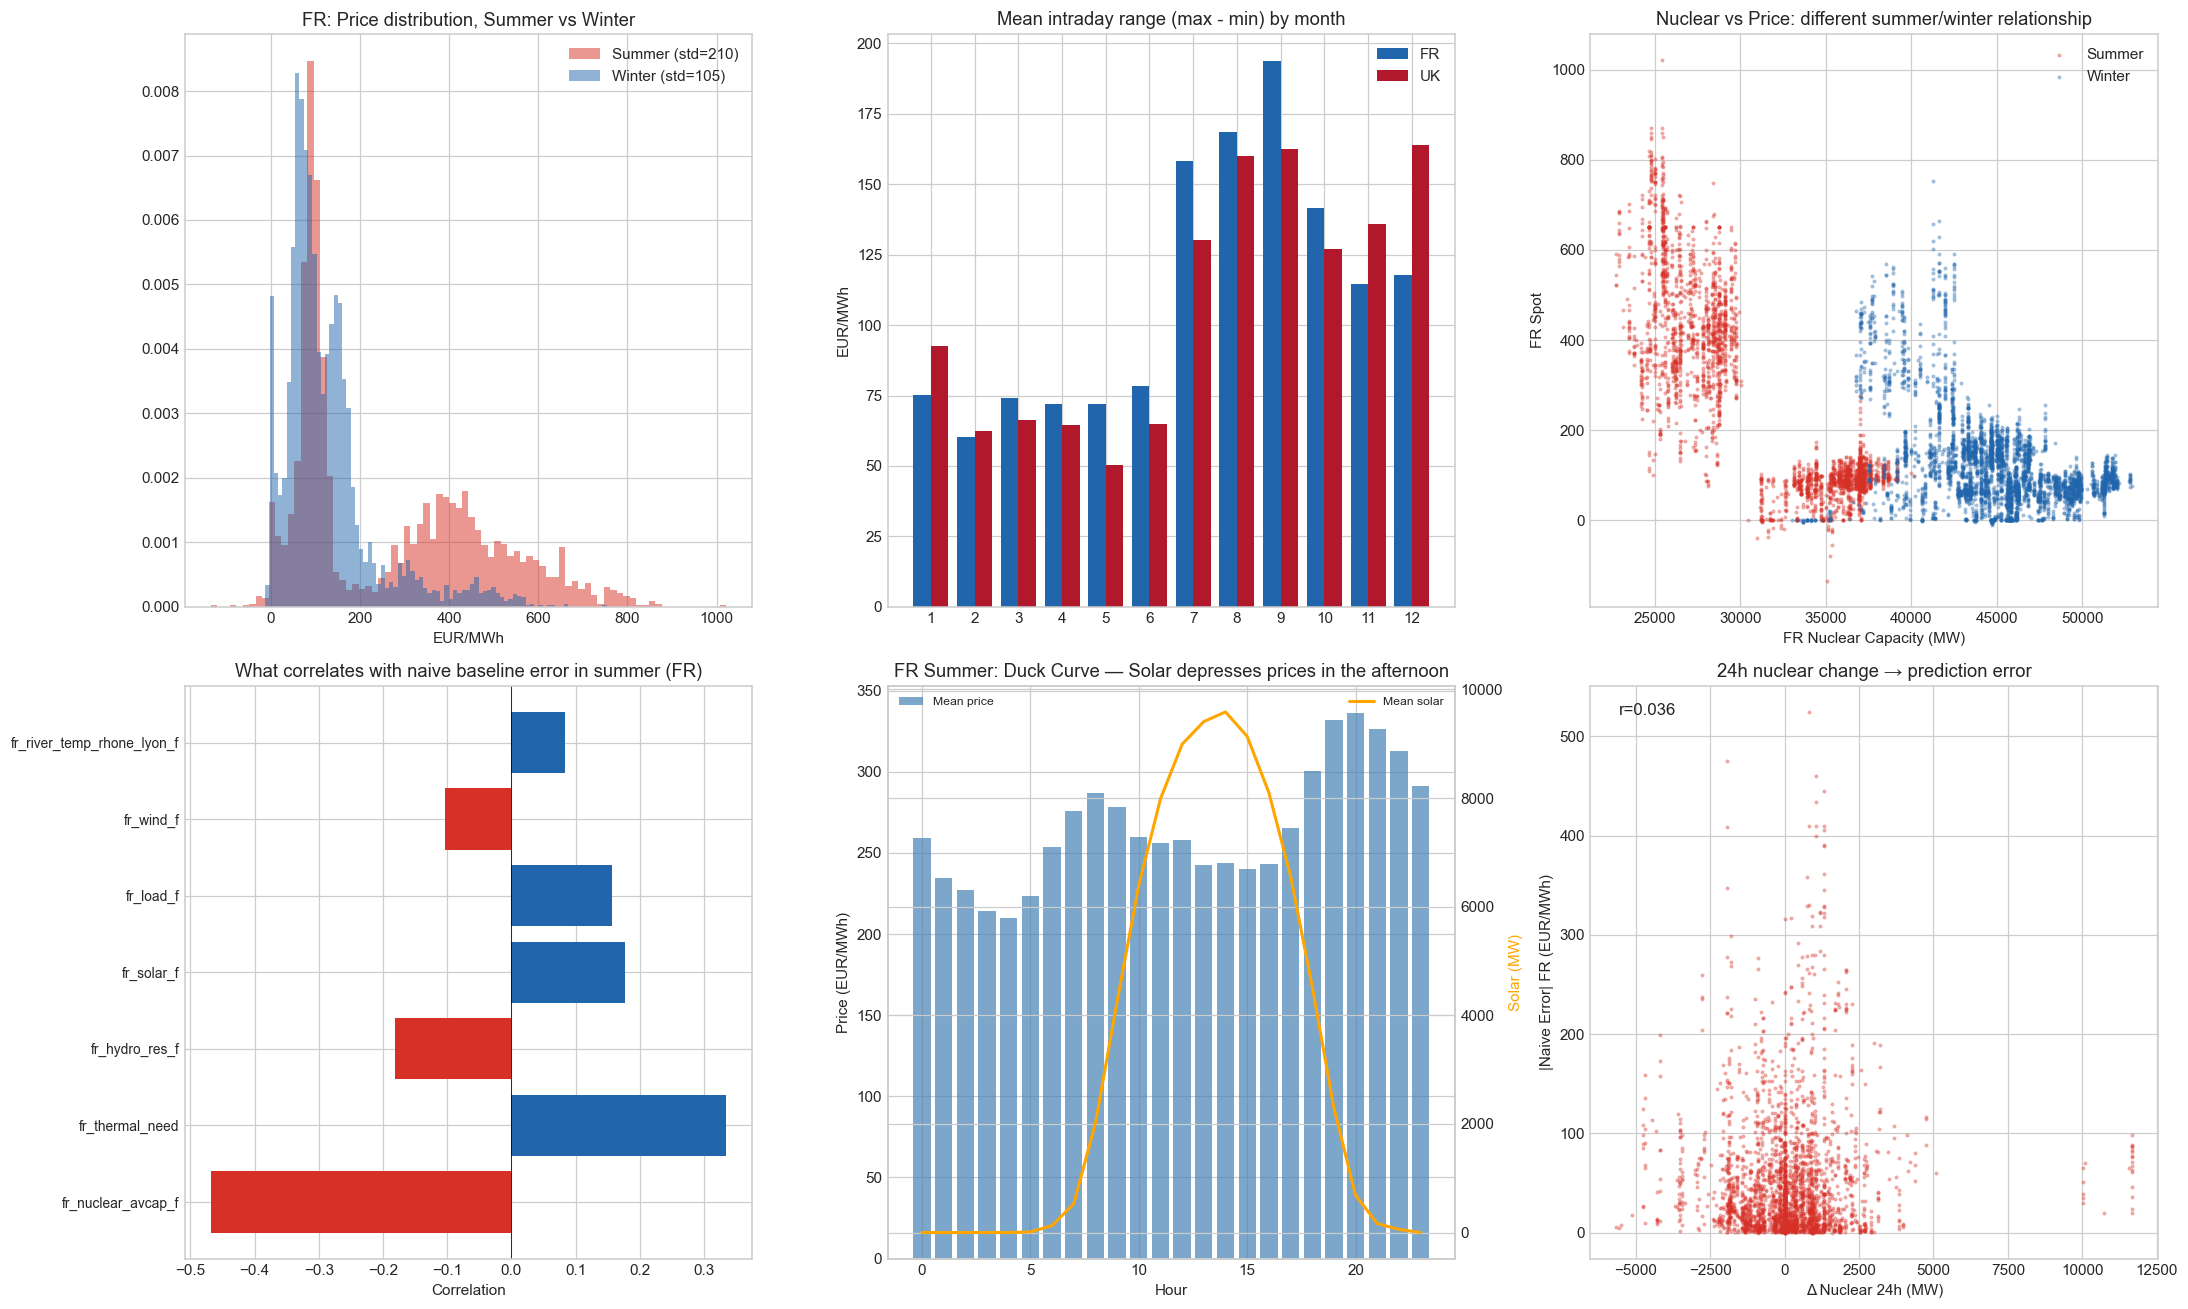


--- Summer vs Winter ---
FR Spot std — Summer: 210.2, Winter: 105.1
UK Spot std — Summer: 170.2, Winter: 108.3
FR Nuclear mean — Summer: 31431 MW, Winter: 45021 MW


In [25]:
# Separate summer (JJA) vs the rest
summer = train[dt.dt.month.isin([7, 8])].copy()
winter = train[dt.dt.month.isin([12, 1, 2])].copy()
rest = train[~dt.dt.month.isin([7, 8])].copy()

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 3a. Price distribution: summer vs winter
axes[0, 0].hist(summer['fr_spot'], bins=80, alpha=0.5, label=f'Summer (std={summer["fr_spot"].std():.0f})', 
                density=True, color='#d73027')
axes[0, 0].hist(winter['fr_spot'], bins=80, alpha=0.5, label=f'Winter (std={winter["fr_spot"].std():.0f})', 
                density=True, color='#2166ac')
axes[0, 0].set_title('FR: Price distribution, Summer vs Winter')
axes[0, 0].set_xlabel('EUR/MWh')
axes[0, 0].legend()

# 3b. Intraday volatility (daily max-min range)
train['date'] = dt.dt.date
daily_range = train.groupby('date').agg(
    fr_range=('fr_spot', lambda x: x.max() - x.min()),
    uk_range=('uk_spot', lambda x: x.max() - x.min()),
    month=('datetime_CET', lambda x: x.dt.month.iloc[0])
)

monthly_range = daily_range.groupby('month').agg(
    fr_mean=('fr_range', 'mean'),
    uk_mean=('uk_range', 'mean')
)
x = np.arange(12)
axes[0, 1].bar(x - 0.2, monthly_range['fr_mean'], 0.4, label='FR', color='#2166ac')
axes[0, 1].bar(x + 0.2, monthly_range['uk_mean'], 0.4, label='UK', color='#b2182b')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(range(1, 13))
axes[0, 1].set_title('Mean intraday range (max - min) by month')
axes[0, 1].set_ylabel('EUR/MWh')
axes[0, 1].legend()

# 3c. In summer: nuclear capacity is the key
axes[0, 2].scatter(summer['fr_nuclear_avcap_f'], summer['fr_spot'], s=3, alpha=0.3, color='#d73027', label='Summer')
axes[0, 2].scatter(winter['fr_nuclear_avcap_f'], winter['fr_spot'], s=3, alpha=0.3, color='#2166ac', label='Winter')
axes[0, 2].set_xlabel('FR Nuclear Capacity (MW)')
axes[0, 2].set_ylabel('FR Spot')
axes[0, 2].set_title('Nuclear vs Price: different summer/winter relationship')
axes[0, 2].legend()

# 3d. 24h naive error — correlation with features in summer
summer['naive_error_fr'] = (summer['fr_spot'] - summer['fr_spot_la']).abs()
summer['naive_error_uk'] = (summer['uk_spot'] - summer['uk_spot_la']).abs()

# Which features explain the biggest naive errors?
error_corr_feats = ['fr_nuclear_avcap_f', 'fr_wind_f', 'fr_solar_f', 'fr_load_f',
                    'fr_hydro_res_f', 'fr_river_temp_rhone_lyon_f', 'fr_thermal_need']
corrs = {f: summer['naive_error_fr'].corr(summer[f]) for f in error_corr_feats if f in summer.columns}
corrs = dict(sorted(corrs.items(), key=lambda x: abs(x[1]), reverse=True))

axes[1, 0].barh(range(len(corrs)), list(corrs.values()), 
                color=['#d73027' if v < 0 else '#2166ac' for v in corrs.values()])
axes[1, 0].set_yticks(range(len(corrs)))
axes[1, 0].set_yticklabels(corrs.keys(), fontsize=9)
axes[1, 0].set_xlabel('Correlation')
axes[1, 0].set_title('What correlates with naive baseline error in summer (FR)')
axes[1, 0].axvline(0, color='black', linewidth=0.5)

# 3e. Solar duck curve? Price by hour in summer
summer_hourly = summer.groupby(summer['datetime_CET'].dt.hour).agg(
    fr_price=('fr_spot', 'mean'),
    fr_solar=('fr_solar_f', 'mean'),
    fr_wind=('fr_wind_f', 'mean'),
)
ax = axes[1, 1]
ax.bar(summer_hourly.index, summer_hourly['fr_price'], color='steelblue', alpha=0.7, label='Mean price')
ax2 = ax.twinx()
ax2.plot(summer_hourly.index, summer_hourly['fr_solar'], color='orange', linewidth=2, label='Mean solar')
ax.set_title('FR Summer: Duck Curve — Solar depresses prices in the afternoon')
ax.set_xlabel('Hour')
ax.set_ylabel('Price (EUR/MWh)')
ax2.set_ylabel('Solar (MW)', color='orange')
ax.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

# 3f. Day-to-day transition in summer (what makes the naive bad)
summer['delta_nuclear_24h'] = summer['fr_nuclear_avcap_f'].diff(24)
mask_big_delta = summer['delta_nuclear_24h'].abs() > 2000
axes[1, 2].scatter(summer['delta_nuclear_24h'], summer['naive_error_fr'], s=3, alpha=0.3, color='#d73027')
axes[1, 2].set_xlabel('Δ Nuclear 24h (MW)')
axes[1, 2].set_ylabel('|Naive Error| FR (EUR/MWh)')
axes[1, 2].set_title('24h nuclear change → prediction error')
r = summer['delta_nuclear_24h'].corr(summer['naive_error_fr'])
axes[1, 2].text(0.05, 0.95, f'r={r:.3f}', transform=axes[1, 2].transAxes, fontsize=11)

plt.tight_layout()
plt.show()

print(f'\n--- Summer vs Winter ---')
print(f'FR Spot std — Summer: {summer["fr_spot"].std():.1f}, Winter: {winter["fr_spot"].std():.1f}')
print(f'UK Spot std — Summer: {summer["uk_spot"].std():.1f}, Winter: {winter["uk_spot"].std():.1f}')
print(f'FR Nuclear mean — Summer: {summer["fr_nuclear_avcap_f"].mean():.0f} MW, Winter: {winter["fr_nuclear_avcap_f"].mean():.0f} MW')

---
## 5. UK Wind — Thresholds and non-linearity

The UK power stack is strongly influenced by wind availability. This section quantifies threshold behavior and non-linear effects on spot prices.

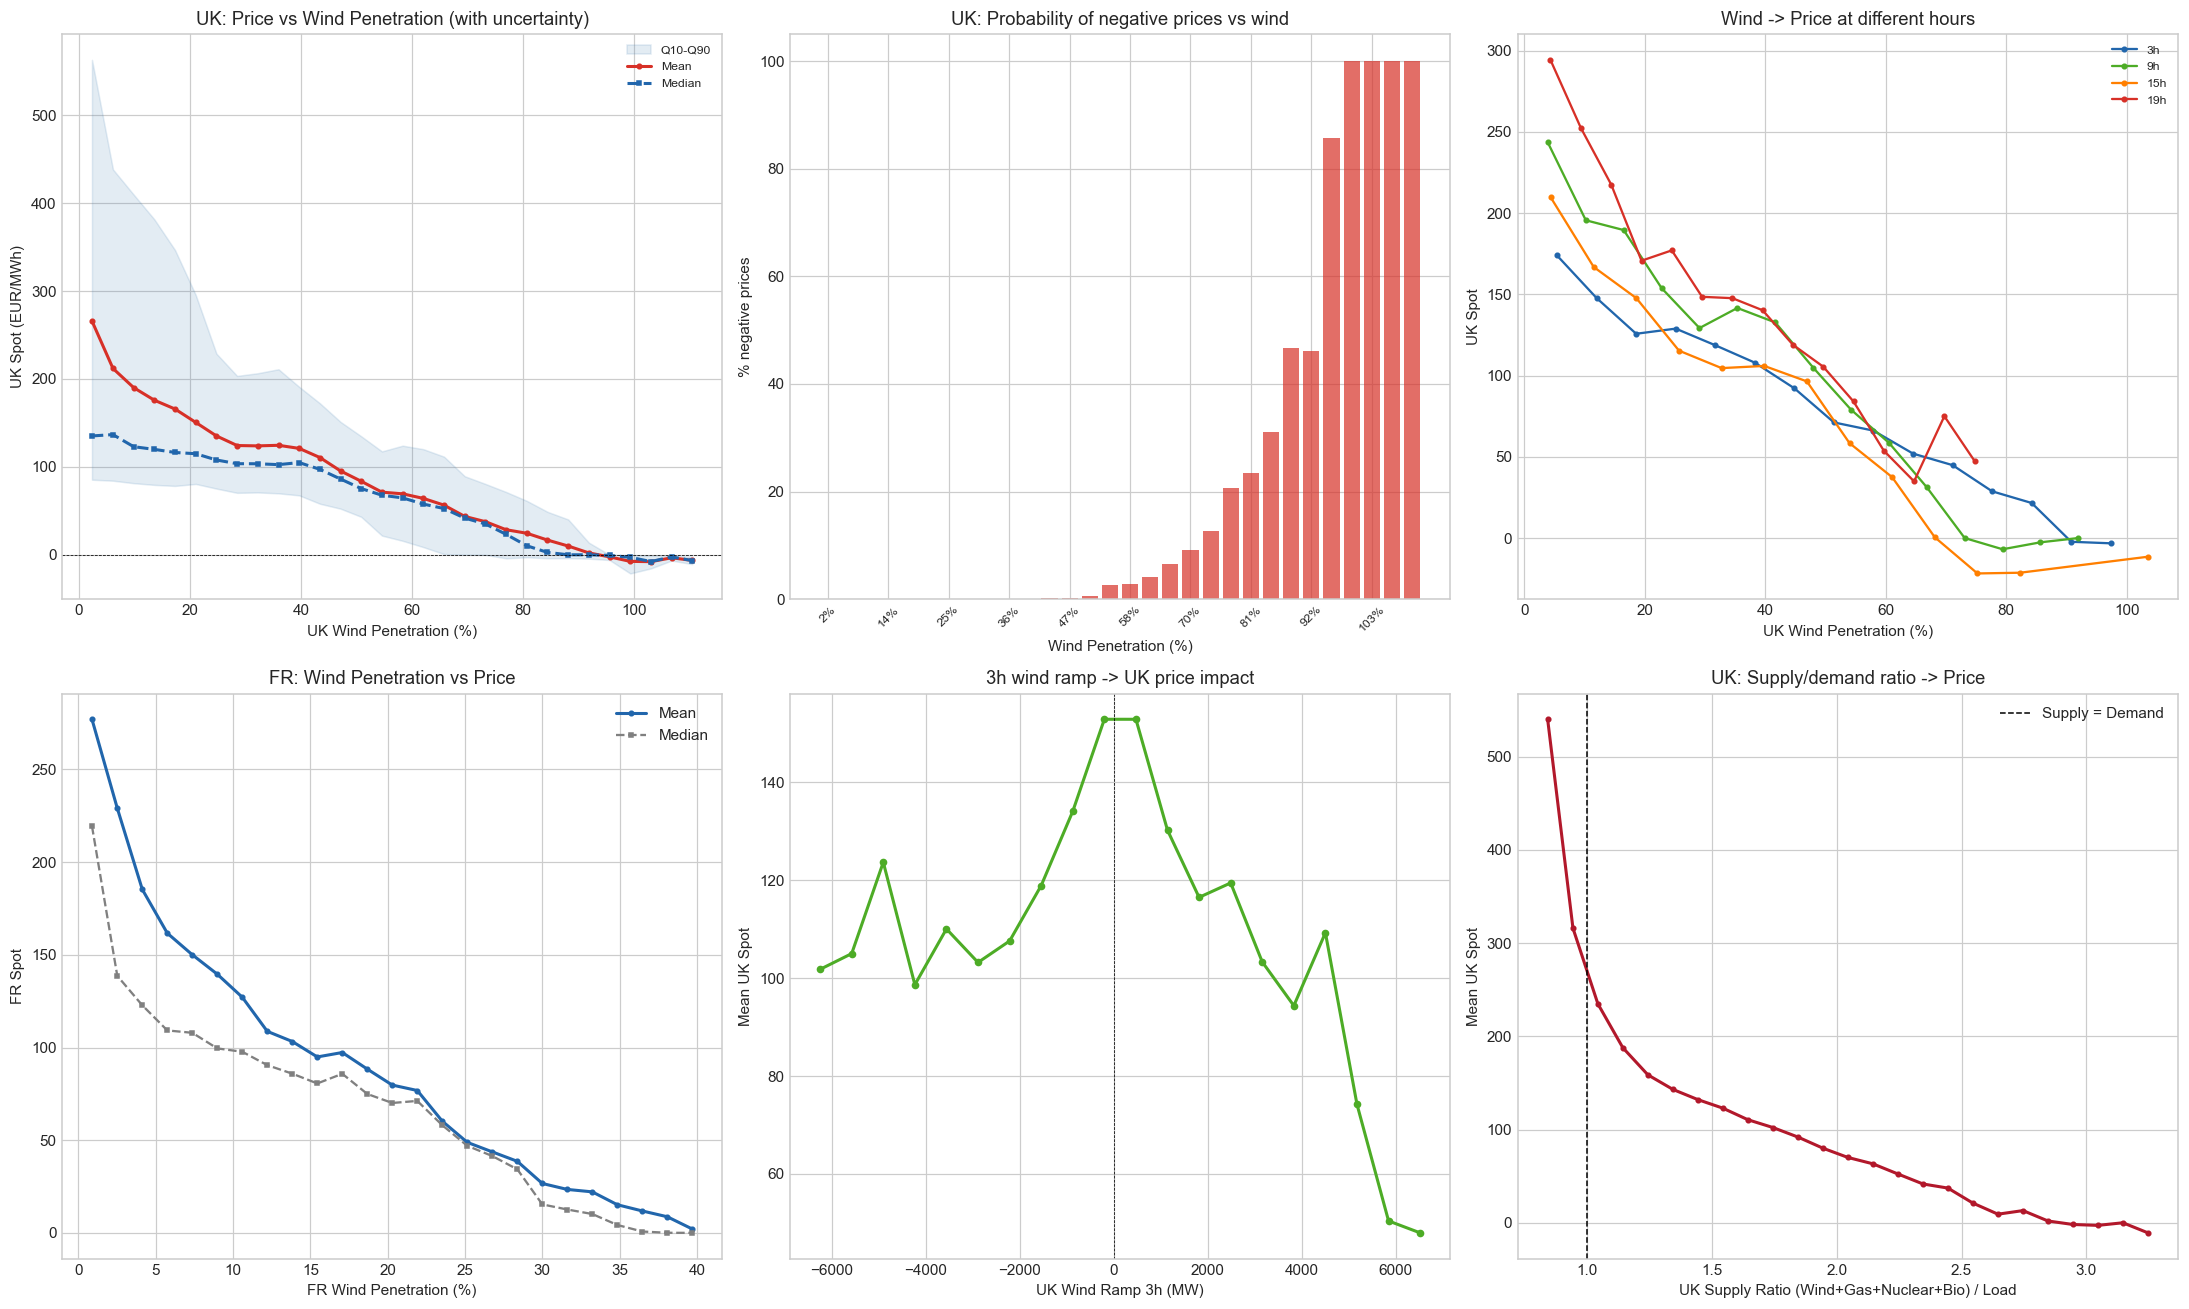

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 5a. Wind penetration binned with quantiles (non-linearity)
wp_bins = pd.cut(train['uk_wind_pen']*100, bins=30)
wp_stats = train.groupby(wp_bins, observed=True)['uk_spot'].agg(
    ['mean', 'median', lambda x: x.quantile(0.1), lambda x: x.quantile(0.9)]
)
wp_stats.columns = ['mean', 'median', 'q10', 'q90']
bin_centers = [(b.left + b.right)/2 for b in wp_stats.index]

ax = axes[0, 0]
ax.fill_between(bin_centers, wp_stats['q10'], wp_stats['q90'], alpha=0.15, color='steelblue', label='Q10-Q90')
ax.plot(bin_centers, wp_stats['mean'], 'o-', color='#d73027', linewidth=2, markersize=3, label='Mean')
ax.plot(bin_centers, wp_stats['median'], 's--', color='#2166ac', linewidth=2, markersize=3, label='Median')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_xlabel('UK Wind Penetration (%)')
ax.set_ylabel('UK Spot (EUR/MWh)')
ax.set_title('UK: Price vs Wind Penetration (with uncertainty)')
ax.legend(fontsize=8)

# 5b. Probability of negative prices vs wind penetration
wp_neg = train.groupby(wp_bins, observed=True)['uk_spot'].apply(lambda x: (x < 0).mean() * 100)
ax = axes[0, 1]
ax.bar(range(len(wp_neg)), wp_neg.values, color='#d73027', alpha=0.7)
ax.set_xticks(range(0, len(wp_neg), 3))
ax.set_xticklabels([f'{bin_centers[i]:.0f}%' for i in range(0, len(bin_centers), 3)], rotation=45, fontsize=8)
ax.set_xlabel('Wind Penetration (%)')
ax.set_ylabel('% negative prices')
ax.set_title('UK: Probability of negative prices vs wind')

# 5c. Wind × Hour interaction (merit order shift by hour)
ax = axes[0, 2]
hours_to_show = [3, 9, 15, 19]  # night, morning, afternoon, evening
colors_h = ['#2166ac', '#4dac26', '#ff7f00', '#d73027']
for h, color in zip(hours_to_show, colors_h):
    mask_h = train['datetime_CET'].dt.hour == h
    wp_h = pd.cut(train.loc[mask_h, 'uk_wind_pen']*100, bins=15)
    mean_h = train.loc[mask_h].groupby(wp_h, observed=True)['uk_spot'].mean()
    centers_h = [(b.left + b.right)/2 for b in mean_h.index]
    ax.plot(centers_h, mean_h.values, 'o-', color=color, linewidth=1.5, markersize=3, label=f'{h}h')
ax.set_xlabel('UK Wind Penetration (%)')
ax.set_ylabel('UK Spot')
ax.set_title('Wind -> Price at different hours')
ax.legend(fontsize=8)

# 5d. FR wind effect (weaker but still present)
fr_wp_bins = pd.cut(train['fr_wind_pen']*100, bins=25)
fr_wp_stats = train.groupby(fr_wp_bins, observed=True)['fr_spot'].agg(['mean', 'median'])
fr_bc = [(b.left + b.right)/2 for b in fr_wp_stats.index]

ax = axes[1, 0]
ax.plot(fr_bc, fr_wp_stats['mean'], 'o-', color='#2166ac', linewidth=2, markersize=3, label='Mean')
ax.plot(fr_bc, fr_wp_stats['median'], 's--', color='gray', linewidth=1.5, markersize=3, label='Median')
ax.set_xlabel('FR Wind Penetration (%)')
ax.set_ylabel('FR Spot')
ax.set_title('FR: Wind Penetration vs Price')
ax.legend()

# 5e + 5f. Wind ramp and supply ratio features (single assign)
wind_supply_features = {
    'uk_wind_ramp_3h': train['uk_wind_f'].diff(3),
    'uk_dispatchable': train['uk_gas_avcap_f'] + train['uk_nuclear_avcap_f'] + train.get('uk_biomass_avcap_f', 0),
}
wind_supply_features['uk_supply_ratio'] = (train['uk_wind_f'] + wind_supply_features['uk_dispatchable']) / train['uk_load_f'].clip(lower=1)
train = train.assign(**wind_supply_features).copy()

ramp_bins = pd.cut(train['uk_wind_ramp_3h'], bins=20)
ramp_price = train.groupby(ramp_bins, observed=True)['uk_spot'].mean()
ramp_centers = [(b.left + b.right)/2 for b in ramp_price.index]

ax = axes[1, 1]
ax.plot(ramp_centers, ramp_price.values, 'o-', color='#4dac26', linewidth=2, markersize=4)
ax.axvline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_xlabel('UK Wind Ramp 3h (MW)')
ax.set_ylabel('Mean UK Spot')
ax.set_title('3h wind ramp -> UK price impact')

sr_bins = pd.cut(train['uk_supply_ratio'], bins=25)
sr_price = train.groupby(sr_bins, observed=True)['uk_spot'].agg(['mean', 'median'])
sr_centers = [(b.left + b.right)/2 for b in sr_price.index]

ax = axes[1, 2]
ax.plot(sr_centers, sr_price['mean'], 'o-', color='#b2182b', linewidth=2, markersize=3)
ax.axvline(1.0, color='black', linewidth=1, linestyle='--', label='Supply = Demand')
ax.set_xlabel('UK Supply Ratio (Wind+Gas+Nuclear+Bio) / Load')
ax.set_ylabel('Mean UK Spot')
ax.set_title('UK: Supply/demand ratio -> Price')
ax.legend()

plt.tight_layout()
plt.show()

---
## 6. Price regimes — 2022 stress vs normalization

The training window includes a marked regime transition. This section compares periods to assess distribution drift and implications for validation design.

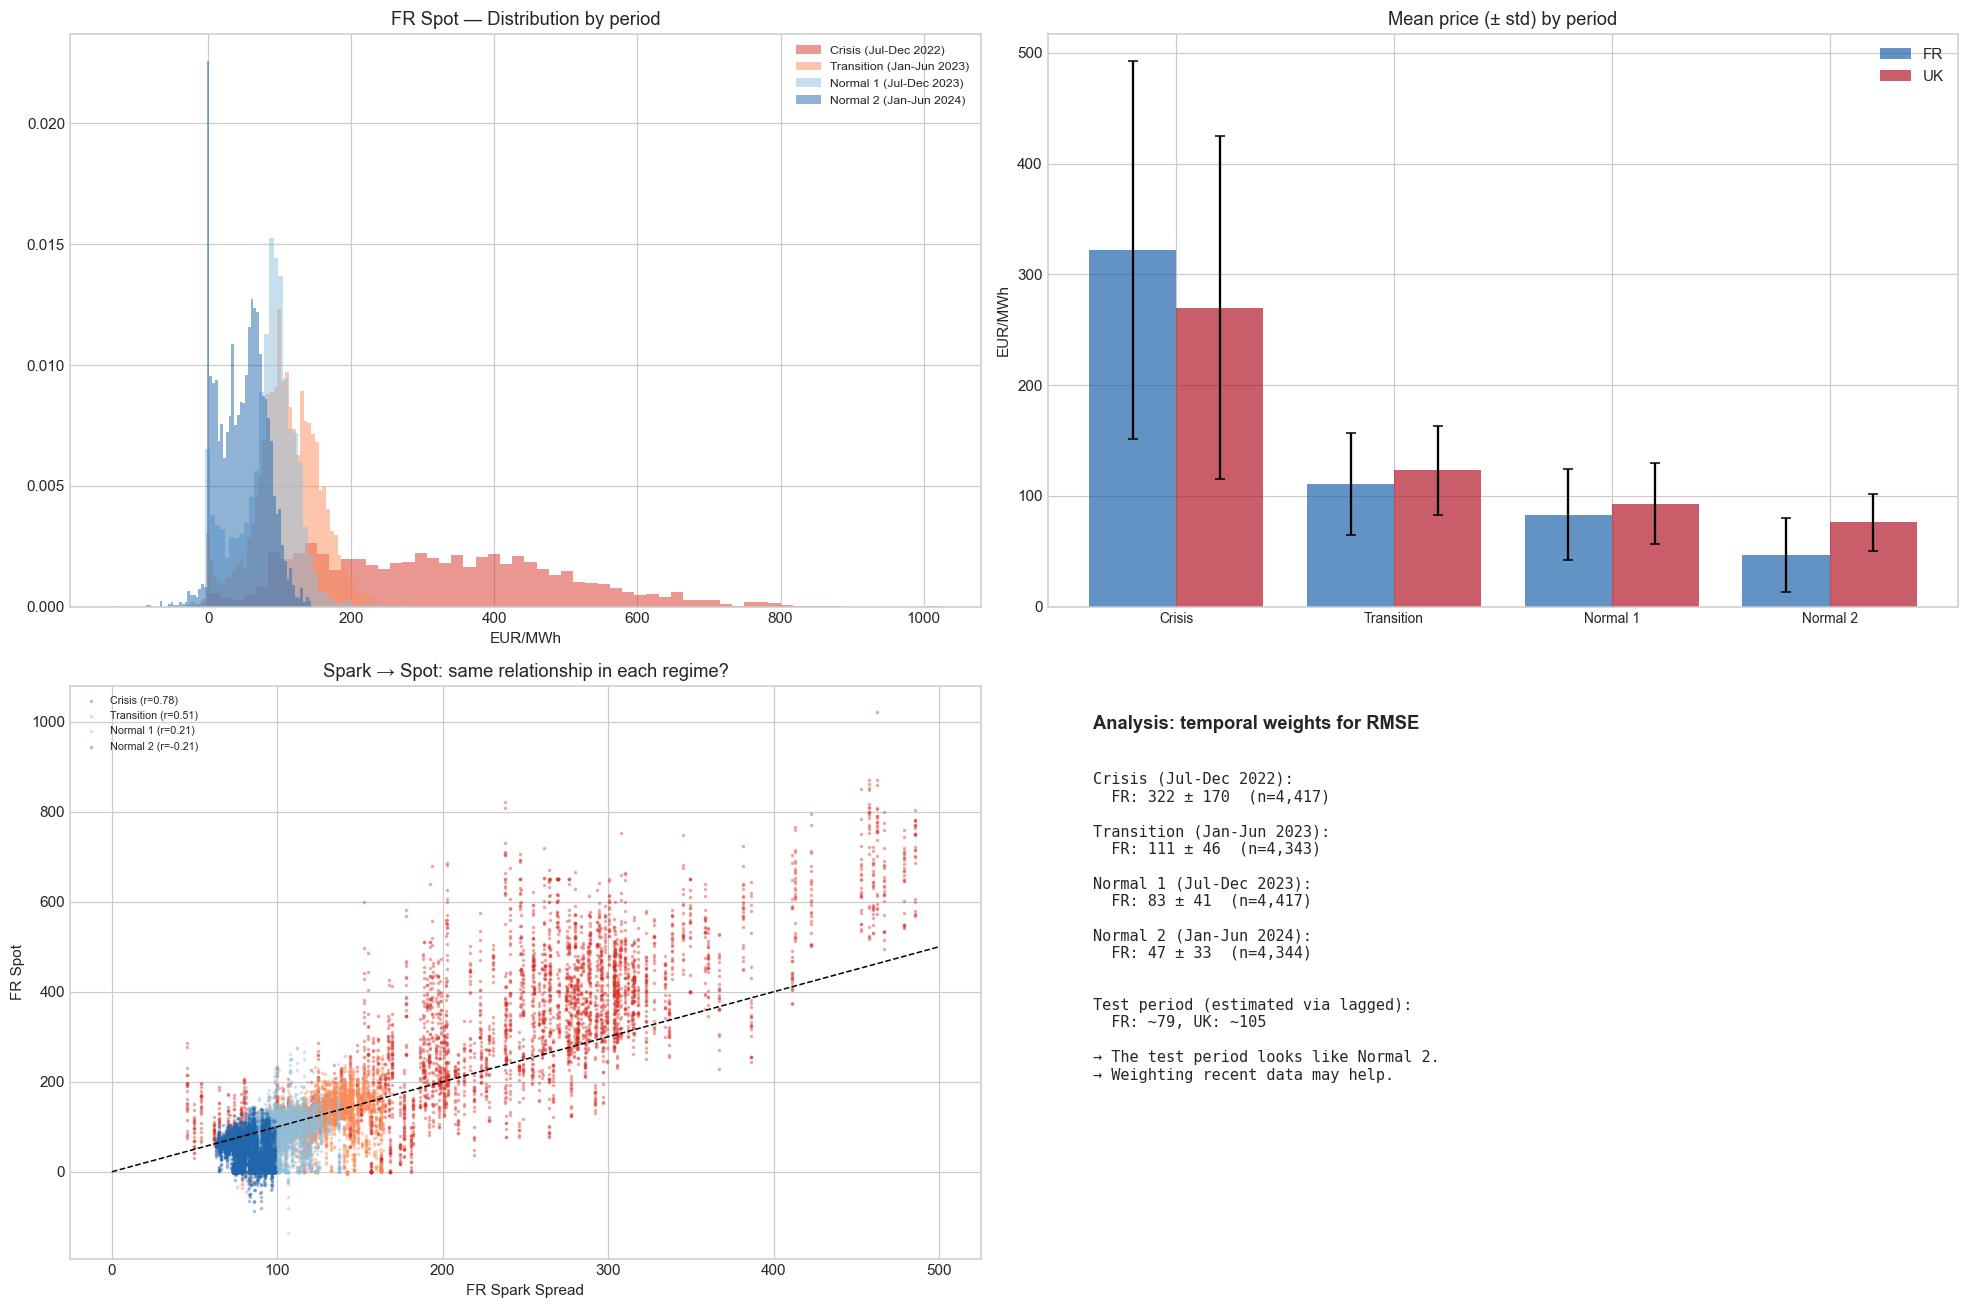


Stats by period :
    Period    FR mean     FR std    UK mean     UK std      Nuclear
    Crisis 321.893674 170.329981 269.775923 154.706356 30593.619266
Transition 110.854497  45.636681 123.149399  39.904117 39031.188536
  Normal 1  83.091784  41.013218  93.160247  36.387171 40295.755205
  Normal 2  46.519210  33.373810  76.135799  25.687935 44285.139712


In [27]:
# Split into 4 periods
periods = {
    'Crisis (Jul-Dec 2022)': (dt >= '2022-07-01') & (dt < '2023-01-01'),
    'Transition (Jan-Jun 2023)': (dt >= '2023-01-01') & (dt < '2023-07-01'),
    'Normal 1 (Jul-Dec 2023)': (dt >= '2023-07-01') & (dt < '2024-01-01'),
    'Normal 2 (Jan-Jun 2024)': (dt >= '2024-01-01') & (dt <= '2024-06-30'),
}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 6a. Price distribution by period
ax = axes[0, 0]
colors = ['#d73027', '#fc8d59', '#91bfdb', '#2166ac']
for (name, mask), color in zip(periods.items(), colors):
    ax.hist(train.loc[mask, 'fr_spot'], bins=60, alpha=0.5, label=name, density=True, color=color)
ax.set_title('FR Spot — Distribution by period')
ax.set_xlabel('EUR/MWh')
ax.legend(fontsize=8)

# 6b. Stats by period
ax = axes[0, 1]
stats = []
for name, mask in periods.items():
    sub = train[mask]
    stats.append({
        'Period': name.split('(')[0].strip(),
        'FR mean': sub['fr_spot'].mean(),
        'FR std': sub['fr_spot'].std(),
        'UK mean': sub['uk_spot'].mean(),
        'UK std': sub['uk_spot'].std(),
        'Nuclear': sub['fr_nuclear_avcap_f'].mean(),
    })
stats_df = pd.DataFrame(stats)

x = np.arange(4)
ax.bar(x - 0.2, stats_df['FR mean'], 0.4, yerr=stats_df['FR std'], capsize=3, label='FR', color='#2166ac', alpha=0.7)
ax.bar(x + 0.2, stats_df['UK mean'], 0.4, yerr=stats_df['UK std'], capsize=3, label='UK', color='#b2182b', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(stats_df['Period'], fontsize=9)
ax.set_title('Mean price (± std) by period')
ax.set_ylabel('EUR/MWh')
ax.legend()

# 6c. Spark-spot correlation by period (is the relationship stable?)
ax = axes[1, 0]
for (name, mask), color in zip(periods.items(), colors):
    sub = train[mask]
    m = sub['fr_spark'].notna()
    r = sub.loc[m, 'fr_spark'].corr(sub.loc[m, 'fr_spot'])
    ax.scatter(sub.loc[m, 'fr_spark'], sub.loc[m, 'fr_spot'], s=2, alpha=0.3, color=color, label=f'{name.split("(")[0].strip()} (r={r:.2f})')
ax.plot([0, 500], [0, 500], 'k--', linewidth=1)
ax.set_xlabel('FR Spark Spread')
ax.set_ylabel('FR Spot')
ax.set_title('Spark → Spot: same relationship in each regime?')
ax.legend(fontsize=7)

# 6d. Optimal weight by period for test RMSE
# Idea: if we weight recent data more, is it better?
ax = axes[1, 1]
ax.text(0.05, 0.95, 'Analysis: temporal weights for RMSE\n', transform=ax.transAxes, fontsize=12,
        verticalalignment='top', fontweight='bold')

text_lines = []
for name, mask in periods.items():
    sub = train[mask]
    fr_mean = sub['fr_spot'].mean()
    fr_std = sub['fr_spot'].std()
    n = mask.sum()
    text_lines.append(f'{name}:\n  FR: {fr_mean:.0f} ± {fr_std:.0f}  (n={n:,})\n')

# Test period estimates (from lagged prices in test)
test_fr_la = x_test['fr_spot_la'].mean()
test_uk_la = x_test['uk_spot_la'].mean()
text_lines.append(f'\nTest period (estimated via lagged):\n  FR: ~{test_fr_la:.0f}, UK: ~{test_uk_la:.0f}')
text_lines.append(f'\n→ The test period looks like Normal 2.')
text_lines.append(f'→ Weighting recent data may help.')

ax.text(0.05, 0.85, '\n'.join(text_lines), transform=ax.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace')
ax.axis('off')

plt.tight_layout()
plt.show()

print('\nStats by period :')
print(stats_df.to_string(index=False))

---
## 7. Interconnector Congestion — FR/UK coupling and decoupling

This section analyzes whether capacity constraints and net flows explain spread widening episodes between FR and UK markets.

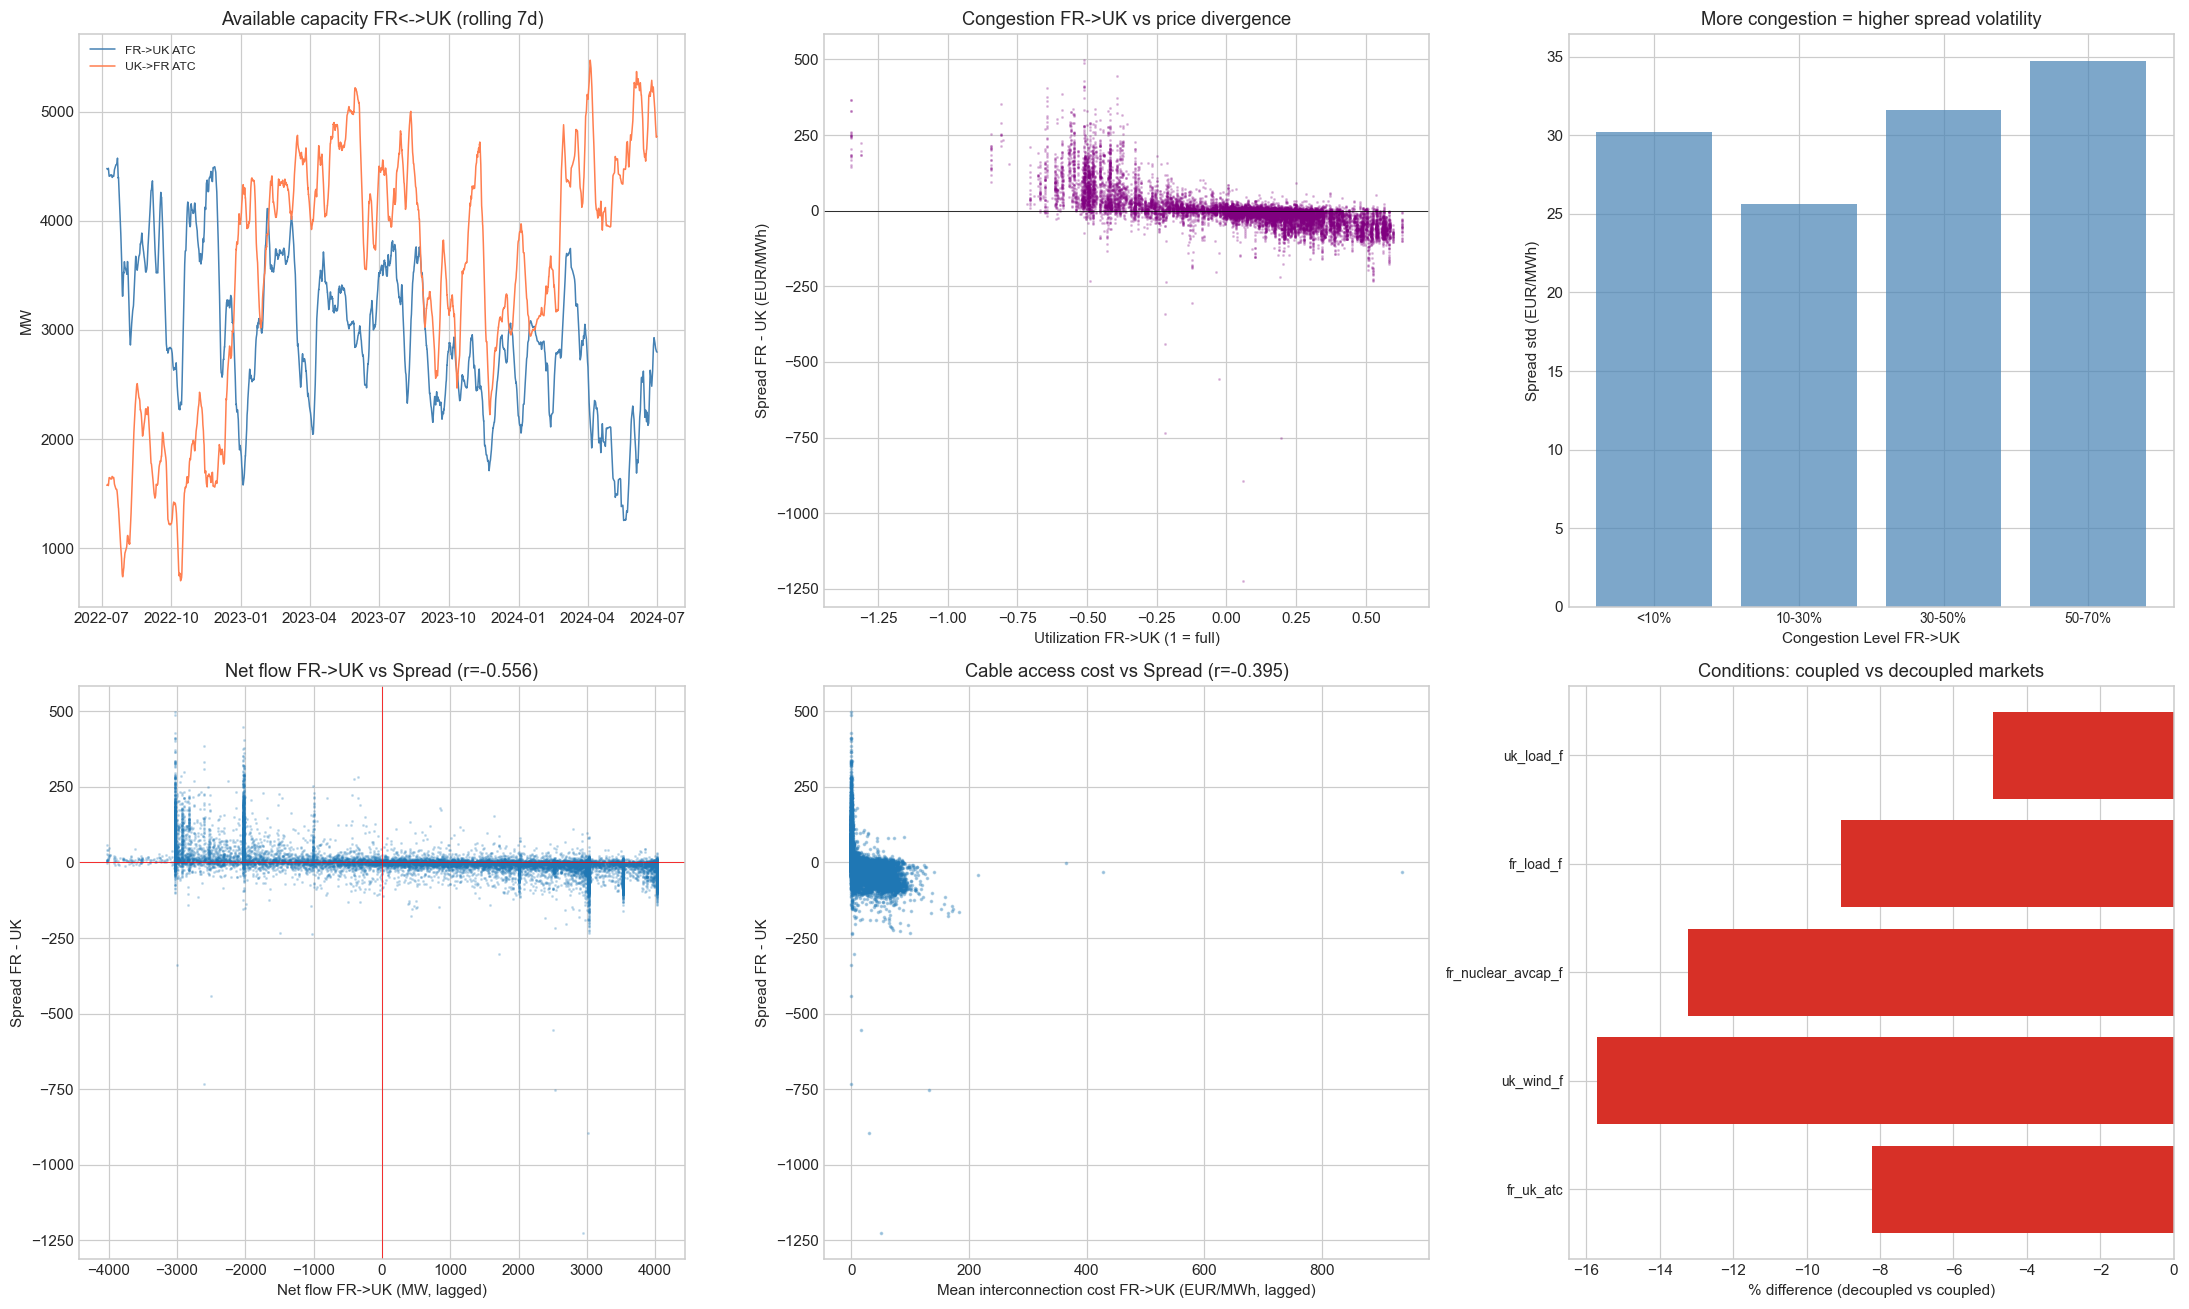


Coupled markets (|spread| < 10): 7278 hours (41.5%)
Decoupled markets (|spread| > 50): 3860 hours (22.0%)


In [28]:
# ATC vs NTC -> utilization rate (single assign to avoid fragmentation)
fr_to_uk = train[['flow_fr-uk-1_la', 'flow_fr-uk-2_la', 'flow_fr-uk-3_la']].sum(axis=1)
uk_to_fr = train[['flow_uk-fr-1_la', 'flow_uk-fr-2_la', 'flow_uk-fr-3_la']].sum(axis=1)

interco_features = {
    'fr_uk_atc': train[['atc_fr-uk-1_f', 'atc_fr-uk-2_f', 'atc_fr-uk-3_f']].sum(axis=1),
    'fr_uk_ntc': train[['ntc_fr-uk-1_f', 'ntc_fr-uk-2_f', 'ntc_fr-uk-3_f']].sum(axis=1),
    'uk_fr_atc': train[['atc_uk-fr-1_f', 'atc_uk-fr-2_f', 'atc_uk-fr-3_f']].sum(axis=1),
    'uk_fr_ntc': train[['ntc_uk-fr-1_f', 'ntc_uk-fr-2_f', 'ntc_uk-fr-3_f']].sum(axis=1),
    'fr_uk_net': fr_to_uk - uk_to_fr,
}
interco_features['fr_uk_util'] = 1 - (interco_features['fr_uk_atc'] / interco_features['fr_uk_ntc'].clip(lower=1))
interco_features['uk_fr_util'] = 1 - (interco_features['uk_fr_atc'] / interco_features['uk_fr_ntc'].clip(lower=1))
train = train.assign(**interco_features).copy()

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 7a. ATC total FR->UK time series
ax = axes[0, 0]
ax.plot(dt, train['fr_uk_atc'].rolling(168).mean(), linewidth=1, color='steelblue', label='FR->UK ATC')
ax.plot(dt, train['uk_fr_atc'].rolling(168).mean(), linewidth=1, color='coral', label='UK->FR ATC')
ax.set_title('Available capacity FR<->UK (rolling 7d)')
ax.set_ylabel('MW')
ax.legend(fontsize=8)

# 7b. Utilization rate vs spread
ax = axes[0, 1]
ax.scatter(train['fr_uk_util'], train['spread_fr_uk'], s=1, alpha=0.2, color='purple')
ax.set_xlabel('Utilization FR->UK (1 = full)')
ax.set_ylabel('Spread FR - UK (EUR/MWh)')
ax.set_title('Congestion FR->UK vs price divergence')
ax.axhline(0, color='black', linewidth=0.5)

# 7c. |Spread| by congestion bucket
congestion_level = pd.cut(
    train['fr_uk_util'].clip(0, 1),
    bins=[0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    labels=['<10%', '10-30%', '30-50%', '50-70%', '70-90%', '>90%']
 )
spread_by_cong = train.groupby(congestion_level, observed=True)['spread_fr_uk'].agg(
    ['mean', 'std', lambda x: (x.abs() > 50).mean() * 100]
)
spread_by_cong.columns = ['mean_spread', 'std_spread', 'pct_big_divergence']

ax = axes[0, 2]
ax.bar(range(len(spread_by_cong)), spread_by_cong['std_spread'], color='steelblue', alpha=0.7)
ax.set_xticks(range(len(spread_by_cong)))
ax.set_xticklabels(spread_by_cong.index, fontsize=9)
ax.set_xlabel('Congestion Level FR->UK')
ax.set_ylabel('Spread std (EUR/MWh)')
ax.set_title('More congestion = higher spread volatility')

# 7d. Net flow vs price difference (lagged)
ax = axes[1, 0]
ax.scatter(train['fr_uk_net'], train['spread_fr_uk'], s=1, alpha=0.2)
ax.set_xlabel('Net flow FR->UK (MW, lagged)')
ax.set_ylabel('Spread FR - UK')
r = train['fr_uk_net'].corr(train['spread_fr_uk'])
ax.set_title(f'Net flow FR->UK vs Spread (r={r:.3f})')
ax.axhline(0, color='red', linewidth=0.5)
ax.axvline(0, color='red', linewidth=0.5)

# 7e. Cost of interconnector vs spread
fr_uk_cost_la = train[['cost_fr-uk-1_la', 'cost_fr-uk-2_la', 'cost_fr-uk-3_la']].mean(axis=1)
r_cost = fr_uk_cost_la.corr(train['spread_fr_uk'])

ax = axes[1, 1]
mask_cost = fr_uk_cost_la.notna() & (fr_uk_cost_la > 0)
ax.scatter(fr_uk_cost_la[mask_cost], train.loc[mask_cost, 'spread_fr_uk'], s=2, alpha=0.3)
ax.set_xlabel('Mean interconnection cost FR->UK (EUR/MWh, lagged)')
ax.set_ylabel('Spread FR - UK')
ax.set_title(f'Cable access cost vs Spread (r={r_cost:.3f})')

# 7f. Summary: when markets are coupled vs decoupled
ax = axes[1, 2]
coupled = train[train['spread_fr_uk'].abs() < 10]  # prices are nearly identical
decoupled = train[train['spread_fr_uk'].abs() > 50]  # strong divergence

compare_feats = ['fr_uk_atc', 'uk_wind_f', 'fr_nuclear_avcap_f', 'fr_load_f', 'uk_load_f']
coupled_means = coupled[compare_feats].mean()
decoupled_means = decoupled[compare_feats].mean()
ratio = (decoupled_means / coupled_means - 1) * 100

colors = ['#d73027' if v < 0 else '#2166ac' for v in ratio]
ax.barh(range(len(ratio)), ratio.values, color=colors)
ax.set_yticks(range(len(ratio)))
ax.set_yticklabels(ratio.index, fontsize=9)
ax.set_xlabel('% difference (decoupled vs coupled)')
ax.set_title('Conditions: coupled vs decoupled markets')
ax.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f'\nCoupled markets (|spread| < 10): {len(coupled)} hours ({100*len(coupled)/len(train):.1f}%)')
print(f'Decoupled markets (|spread| > 50): {len(decoupled)} hours ({100*len(decoupled)/len(train):.1f}%)')

---
## 8. Summary — Candidate features and priorities

In [30]:
# Dynamic summary of candidate features (robust to partial notebook execution)
candidates = {}
missing_candidates = []

def add_candidate(name, series=None, required_cols=None, builder=None):
    """Add a candidate series if available, otherwise track as missing."""
    if series is not None:
        candidates[name] = series
        return

    if builder is not None:
        if required_cols is None or all(col in train.columns for col in required_cols):
            candidates[name] = builder()
        else:
            missing_candidates.append(name)
        return

    missing_candidates.append(name)

# Core features from earlier cells
add_candidate('fr_spark', series=train['fr_spark'] if 'fr_spark' in train.columns else None)
add_candidate('uk_spark', series=train['uk_spark'] if 'uk_spark' in train.columns else None)
add_candidate('fr_thermal_need', series=train['fr_thermal_need'] if 'fr_thermal_need' in train.columns else None)
add_candidate('uk_thermal_need', series=train['uk_thermal_need'] if 'uk_thermal_need' in train.columns else None)
add_candidate('fr_wind_pen', series=train['fr_wind_pen'] if 'fr_wind_pen' in train.columns else None)
add_candidate('uk_wind_pen', series=train['uk_wind_pen'] if 'uk_wind_pen' in train.columns else None)

# Optional engineered features from specific sections
add_candidate('baseload_gap', series=train['baseload_gap'] if 'baseload_gap' in train.columns else None)
add_candidate('fr_uk_net_flow', series=train['fr_uk_net'] if 'fr_uk_net' in train.columns else None)
add_candidate('fr_uk_atc', series=train['fr_uk_atc'] if 'fr_uk_atc' in train.columns else None)
add_candidate('fr_uk_util', series=train['fr_uk_util'] if 'fr_uk_util' in train.columns else None)
add_candidate('uk_wind_ramp_3h', series=train['uk_wind_ramp_3h'] if 'uk_wind_ramp_3h' in train.columns else None)
add_candidate(
    'nuke_change_24h',
    series=train['nuke_change_24h'] if 'nuke_change_24h' in train.columns else None,
    required_cols=['fr_nuclear_avcap_f'],
    builder=lambda: train['fr_nuclear_avcap_f'].diff(24),
)
add_candidate(
    'spread_fr_uk_la',
    required_cols=['fr_spot_la', 'uk_spot_la'],
    builder=lambda: train['fr_spot_la'] - train['uk_spot_la'],
)
add_candidate(
    'fr_uk_cost_la',
    required_cols=['cost_fr-uk-1_la', 'cost_fr-uk-2_la', 'cost_fr-uk-3_la'],
    builder=lambda: train[['cost_fr-uk-1_la', 'cost_fr-uk-2_la', 'cost_fr-uk-3_la']].mean(axis=1),
)

rows = []
for name, series in candidates.items():
    rows.append({
        'Feature': name,
        'r(FR spot)': series.corr(train['fr_spot']),
        'r(UK spot)': series.corr(train['uk_spot']),
    })

if not rows:
    raise ValueError('No candidate features available. Run the setup and feature-engineering sections before this summary cell.')

corr_df = pd.DataFrame(rows)
corr_df['max|r|'] = corr_df[['r(FR spot)', 'r(UK spot)']].abs().max(axis=1)
corr_df = corr_df.sort_values('max|r|', ascending=False).reset_index(drop=True)

print('=' * 76)
print('FEATURE CANDIDATES - EDA DEEP DIVES (ranked by max |correlation|)')
print('=' * 76)
print(corr_df[['Feature', 'r(FR spot)', 'r(UK spot)', 'max|r|']].round(3).to_string(index=False))

if missing_candidates:
    print('\nSkipped (not available in current kernel state):')
    for feat in sorted(set(missing_candidates)):
        print(f'  - {feat}')

# Priority buckets driven by measured correlation strength
high = corr_df[corr_df['max|r|'] >= 0.50]['Feature'].tolist()
medium = corr_df[(corr_df['max|r|'] >= 0.30) & (corr_df['max|r|'] < 0.50)]['Feature'].tolist()
explore = corr_df[corr_df['max|r|'] < 0.30]['Feature'].tolist()

print('\n' + '=' * 76)
print('FEATURE PRIORITIZATION')
print('=' * 76)
print('High priority   (|r| >= 0.50):')
if high:
    for feat in high:
        print(f'  - {feat}')
else:
    print('  - None')

print('\nMedium priority (0.30 <= |r| < 0.50):')
if medium:
    for feat in medium:
        print(f'  - {feat}')
else:
    print('  - None')

print('\nExplore / interactions (|r| < 0.30):')
if explore:
    for feat in explore:
        print(f'  - {feat}')
else:
    print('  - None')

# Practical modeling notes inferred from diagnostics
notes = []
if {'fr_spark', 'uk_spark'}.issubset(set(high + medium)):
    notes.append('Spark spread remains a core explanatory signal in both markets.')
if 'uk_wind_pen' in high + medium:
    notes.append('UK wind penetration should be modeled non-linearly (threshold effects).')
if 'fr_uk_util' in high + medium or 'fr_uk_net_flow' in high + medium:
    notes.append('Interconnector congestion/flows carry regime information for spread risk.')
if 'nuke_change_24h' in high + medium:
    notes.append('Nuclear transition dynamics matter for FR short-term price formation.')

print('\n' + '=' * 76)
print('MODELING NOTES')
print('=' * 76)
if notes:
    for note in notes:
        print(f'- {note}')
else:
    print('- No dominant single signal; favor interaction terms and robust ensembling.')

FEATURE CANDIDATES - EDA DEEP DIVES (ranked by max |correlation|)
        Feature  r(FR spot)  r(UK spot)  max|r|
       fr_spark       0.888       0.858   0.888
       uk_spark       0.870       0.880   0.880
     fr_uk_util      -0.690      -0.504   0.690
fr_thermal_need       0.675       0.619   0.675
 fr_uk_net_flow      -0.612      -0.480   0.612
spread_fr_uk_la       0.551       0.347   0.551
      fr_uk_atc       0.433       0.295   0.433
    uk_wind_pen      -0.325      -0.415   0.415
uk_thermal_need       0.314       0.407   0.407
    fr_wind_pen      -0.374      -0.322   0.374
  fr_uk_cost_la      -0.301      -0.173   0.301
nuke_change_24h       0.046       0.051   0.051
uk_wind_ramp_3h       0.019       0.006   0.019

Skipped (not available in current kernel state):
  - baseload_gap

FEATURE PRIORITIZATION
High priority   (|r| >= 0.50):
  - fr_spark
  - uk_spark
  - fr_uk_util
  - fr_thermal_need
  - fr_uk_net_flow
  - spread_fr_uk_la

Medium priority (0.30 <= |r| < 0.50):
 